In [7]:
pip install pykrige


Note: you may need to restart the kernel to use updated packages.


# SOC Modeling Approach 1


================ CAMBISOLS =================


C:\Users\grs05\AppData\Local\Temp\ipykernel_9984\2090022869.py:32: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
C:\Users\grs05\AppData\Local\Temp\ipykernel_9984\2090022869.py:33: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["SAR_DATE"] = pd.to_datetime(df["SAR_DATE"], dayfirst=True, errors="coerce")



--- Baseline Performance ---
R2: 0.6663
RMSE: 0.1436
MAE: 0.0974
MAPE: 22.0193
Fitting 3 folds for each of 25 candidates, totalling 75 fits

--- Tuned Performance ---
R2: 0.6885
RMSE: 0.1387
MAE: 0.0948
MAPE: 21.2852

Best Hyperparameters:
{'n_estimators': 800, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 25}


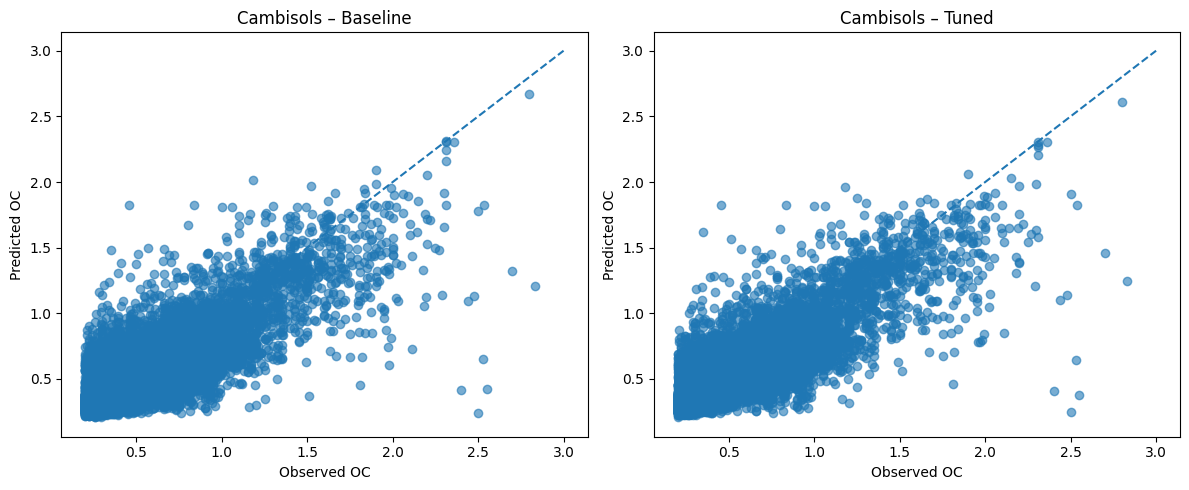


================ LUVISOLS =================


C:\Users\grs05\AppData\Local\Temp\ipykernel_9984\2090022869.py:32: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
C:\Users\grs05\AppData\Local\Temp\ipykernel_9984\2090022869.py:33: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["SAR_DATE"] = pd.to_datetime(df["SAR_DATE"], dayfirst=True, errors="coerce")



--- Baseline Performance ---
R2: 0.6001
RMSE: 0.1600
MAE: 0.1060
MAPE: 23.1386
Fitting 3 folds for each of 25 candidates, totalling 75 fits

--- Tuned Performance ---
R2: 0.6440
RMSE: 0.1510
MAE: 0.1000
MAPE: 21.7042

Best Hyperparameters:
{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 25}


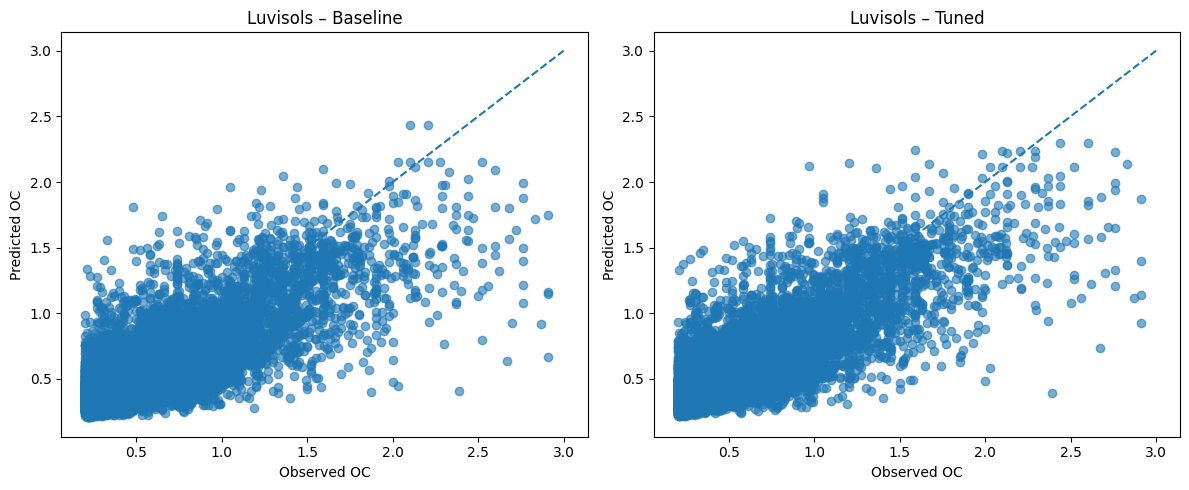


================ VERTISOLS =================


C:\Users\grs05\AppData\Local\Temp\ipykernel_9984\2090022869.py:32: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
C:\Users\grs05\AppData\Local\Temp\ipykernel_9984\2090022869.py:33: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["SAR_DATE"] = pd.to_datetime(df["SAR_DATE"], dayfirst=True, errors="coerce")



--- Baseline Performance ---
R2: 0.5377
RMSE: 0.2098
MAE: 0.1423
MAPE: 27.6645
Fitting 3 folds for each of 25 candidates, totalling 75 fits

--- Tuned Performance ---
R2: 0.5761
RMSE: 0.2009
MAE: 0.1385
MAPE: 27.0457

Best Hyperparameters:
{'n_estimators': 800, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 15}


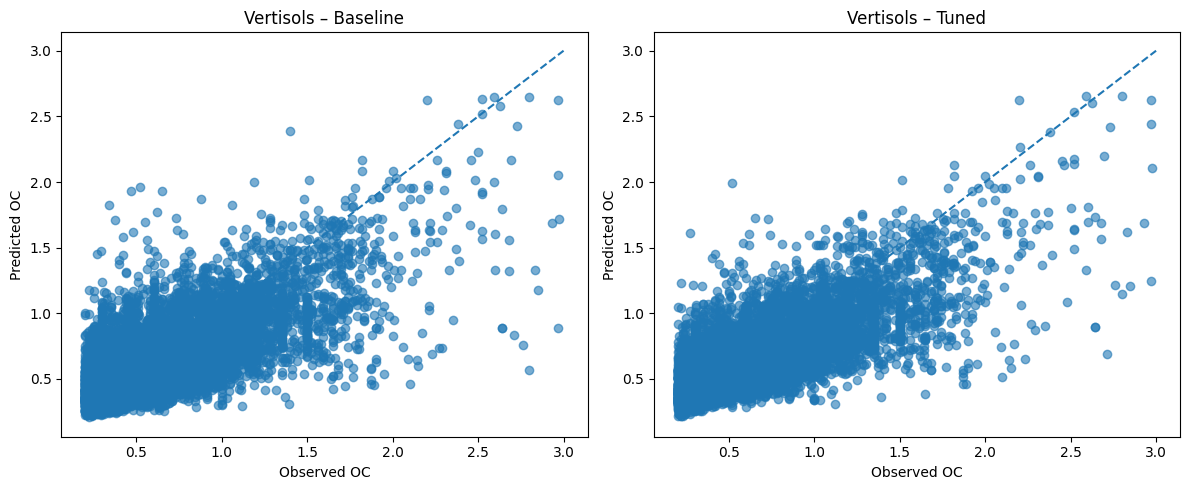


ALL SOIL MODELS TRAINED AND SAVED SUCCESSFULLY ✔


In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ============================================================
# PATHS
# ============================================================
DATA_DIR = r"H:\Final Data"
MODEL_DIR = r"H:\Final Data\SOC Models"
os.makedirs(MODEL_DIR, exist_ok=True)

soil_files = [
    "India_SHC_Cambisols_Terrain_MERGED.csv",
    "India_SHC_Luvisols_Terrain_MERGED.csv",
    "India_SHC_Vertisols_Terrain_MERGED.csv"
]

# ============================================================
# FEATURE ENGINEERING FUNCTION
# ============================================================
def feature_engineering(df):
    eps = 1e-6

    # Dates
    df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
    df["SAR_DATE"] = pd.to_datetime(df["SAR_DATE"], dayfirst=True, errors="coerce")
    df["tile_date"] = pd.to_datetime(df["tile_date"], format="%Y%m%d", errors="coerce")

    # Vegetation
    df["NDVI"] = (df["B8"] - df["B4"]) / (df["B8"] + df["B4"] + eps)
    df["EVI"] = 2.5 * (df["B8"] - df["B4"]) / (df["B8"] + 6*df["B4"] - 7.5*df["B2"] + 1)
    df["SAVI"] = 1.5 * (df["B8"] - df["B4"]) / (df["B8"] + df["B4"] + 0.5)

    # Red-edge
    df["NDRE"] = (df["B8"] - df["B5"]) / (df["B8"] + df["B5"] + eps)
    df["CI_RE"] = (df["B8"] / (df["B5"] + eps)) - 1

    # Soil
    df["BSI"] = (
        (df["B11"] + df["B4"] - df["B8"] - df["B2"]) /
        (df["B11"] + df["B4"] + df["B8"] + df["B2"] + eps)
    )
    df["NDTI"] = (df["B11"] - df["B12"]) / (df["B11"] + df["B12"] + eps)
    df["BI"] = np.sqrt(df["B4"]**2 + df["B3"]**2)

    # Moisture
    df["NDWI"] = (df["B8"] - df["B11"]) / (df["B8"] + df["B11"] + eps)
    df["LSWI"] = (df["B8"] - df["B12"]) / (df["B8"] + df["B12"] + eps)

    # SAR
    df["VV_VH_ratio"] = df["VV"] / (df["VH"] + eps)
    df["VV_minus_VH"] = df["VV"] - df["VH"]
    df["log_VV"] = np.log(np.abs(df["VV"]) + 1)
    df["log_VH"] = np.log(np.abs(df["VH"]) + 1)

    # Terrain
    df["slope_norm"] = np.log1p(df["slope"])
    df["elev_range_90m"] = df["elev_max_90m"] - df["elev_min_90m"]

    # Temporal
    df["DOY"] = df["date"].dt.dayofyear
    df["month"] = df["date"].dt.month
    df["sar_optical_gap_days"] = (df["date"] - df["SAR_DATE"]).dt.days

    return df

# ============================================================
# METRIC FUNCTION
# ============================================================
def regression_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE": np.mean(np.abs((y_true - y_pred) / (y_true + 1e-6))) * 100
    }

# ============================================================
# LOOP OVER SOILS
# ============================================================
for file in soil_files:
    soil_name = file.split("_")[2]
    print(f"\n================ {soil_name.upper()} =================")

    df = pd.read_csv(os.path.join(DATA_DIR, file))
    df = feature_engineering(df)

    target = "OC"
    drop_cols = [
        "system:index", "tile_id", ".geo",
        "date", "SAR_DATE", "tile_date",
        "SOIL_CLASS", target
    ]

    X = df.drop(columns=drop_cols, errors="ignore")
    y = df[target]

    # Drop unwanted
    X = X.drop(columns=[
        "Band_SCL", "cloud_cover",
        "days_from_survey", "sar_optical_gap_days"
    ], errors="ignore")

    # One-hot climate
    X = pd.get_dummies(X, columns=["CLIMATE_ZONE"], drop_first=True)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.10, random_state=42
    )

    # ========================================================
    # BASELINE MODEL
    # ========================================================
    rf_base = RandomForestRegressor(
        n_estimators=400,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42
    )
    rf_base.fit(X_train, y_train)
    y_pred_base = rf_base.predict(X_test)

    base_metrics = regression_metrics(y_test, y_pred_base)

    print("\n--- Baseline Performance ---")
    for k, v in base_metrics.items():
        print(f"{k}: {v:.4f}")

    # Save baseline model
    joblib.dump(
        rf_base,
        os.path.join(MODEL_DIR, f"SOC_RF_{soil_name}_BASE.pkl")
    )

    # ========================================================
    # HYPERPARAMETER TUNING
    # ========================================================
    param_grid = {
        "n_estimators": [300, 500, 800],
        "max_depth": [None, 15, 25, 40],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", 0.3, 0.5]
    }

    search = RandomizedSearchCV(
        RandomForestRegressor(n_jobs=-1, random_state=42),
        param_grid,
        n_iter=25,
        scoring="r2",
        cv=3,
        verbose=1
    )

    search.fit(X_train, y_train)
    rf_tuned = search.best_estimator_

    y_pred_tuned = rf_tuned.predict(X_test)
    tuned_metrics = regression_metrics(y_test, y_pred_tuned)

    print("\n--- Tuned Performance ---")
    for k, v in tuned_metrics.items():
        print(f"{k}: {v:.4f}")

    print("\nBest Hyperparameters:")
    print(search.best_params_)

    # Save tuned model
    joblib.dump(
        rf_tuned,
        os.path.join(MODEL_DIR, f"SOC_RF_{soil_name}_TUNED.pkl")
    )

    # ========================================================
    # PLOTS (BEFORE & AFTER)
    # ========================================================
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    ax[0].scatter(y_test, y_pred_base, alpha=0.6)
    ax[0].plot([y.min(), y.max()], [y.min(), y.max()], "--")
    ax[0].set_title(f"{soil_name} – Baseline")

    ax[1].scatter(y_test, y_pred_tuned, alpha=0.6)
    ax[1].plot([y.min(), y.max()], [y.min(), y.max()], "--")
    ax[1].set_title(f"{soil_name} – Tuned")

    for a in ax:
        a.set_xlabel("Observed OC")
        a.set_ylabel("Predicted OC")

    plt.tight_layout()
    plt.show()

print("\nALL SOIL MODELS TRAINED AND SAVED SUCCESSFULLY ✔")


# Monte Carlo PPD Trial Run

Model 1 Prediction: 0.5755
Model 2 Prediction: 0.5701
Model 3 Prediction: 0.5866
Model 4 Prediction: 0.5747
Model 5 Prediction: 0.5615
Model 6 Prediction: 0.5862
Model 7 Prediction: 0.5750
Model 8 Prediction: 0.5811
Model 9 Prediction: 0.5836
Model 10 Prediction: 0.5563
Model 11 Prediction: 0.5623
Model 12 Prediction: 0.5718
Model 13 Prediction: 0.5685
Model 14 Prediction: 0.5851
Model 15 Prediction: 0.5730
Model 16 Prediction: 0.5791
Model 17 Prediction: 0.5873
Model 18 Prediction: 0.5696
Model 19 Prediction: 0.5537
Model 20 Prediction: 0.5725
Model 21 Prediction: 0.5711
Model 22 Prediction: 0.5726
Model 23 Prediction: 0.5763
Model 24 Prediction: 0.5790
Model 25 Prediction: 0.5736
Model 26 Prediction: 0.5626
Model 27 Prediction: 0.5663
Model 28 Prediction: 0.5850
Model 29 Prediction: 0.5719
Model 30 Prediction: 0.5668
Model 31 Prediction: 0.5721
Model 32 Prediction: 0.5562
Model 33 Prediction: 0.5662
Model 34 Prediction: 0.5725
Model 35 Prediction: 0.5732
Model 36 Prediction: 0.5788
M

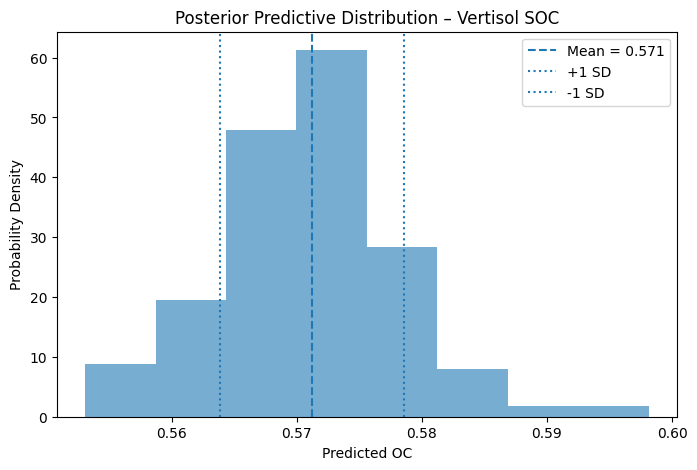

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# ============================================================
# FILE PATH
# ============================================================
FILE_PATH = r"H:\Final Data\India_SHC_Vertisols_Terrain_MERGED.csv"

# ============================================================
# FEATURE ENGINEERING (Robust Version)
# ============================================================
def feature_engineering(df):

    eps = 1e-6

    # ---------- Dates ----------
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df["DOY"] = df["date"].dt.dayofyear
        df["month"] = df["date"].dt.month

    if "SAR_DATE" in df.columns:
        df["SAR_DATE"] = pd.to_datetime(df["SAR_DATE"], errors="coerce")

    if "tile_date" in df.columns:
        df["tile_date"] = pd.to_datetime(df["tile_date"], format="%Y%m%d", errors="coerce")

    if "date" in df.columns and "SAR_DATE" in df.columns:
        df["sar_optical_gap_days"] = (df["date"] - df["SAR_DATE"]).dt.days

    # ---------- Vegetation ----------
    df["NDVI"] = (df["B8"] - df["B4"]) / (df["B8"] + df["B4"] + eps)
    df["EVI"] = 2.5 * (df["B8"] - df["B4"]) / (df["B8"] + 6*df["B4"] - 7.5*df["B2"] + 1)
    df["SAVI"] = 1.5 * (df["B8"] - df["B4"]) / (df["B8"] + df["B4"] + 0.5)

    # ---------- Red Edge ----------
    df["NDRE"] = (df["B8"] - df["B5"]) / (df["B8"] + df["B5"] + eps)
    df["CI_RE"] = (df["B8"] / (df["B5"] + eps)) - 1

    # ---------- Soil ----------
    df["BSI"] = (
        (df["B11"] + df["B4"] - df["B8"] - df["B2"]) /
        (df["B11"] + df["B4"] + df["B8"] + df["B2"] + eps)
    )

    df["NDTI"] = (df["B11"] - df["B12"]) / (df["B11"] + df["B12"] + eps)
    df["BI"] = np.sqrt(df["B4"]**2 + df["B3"]**2)

    # ---------- Moisture ----------
    df["NDWI"] = (df["B8"] - df["B11"]) / (df["B8"] + df["B11"] + eps)
    df["LSWI"] = (df["B8"] - df["B12"]) / (df["B8"] + df["B12"] + eps)

    # ---------- SAR ----------
    df["VV_VH_ratio"] = df["VV"] / (df["VH"] + eps)
    df["VV_minus_VH"] = df["VV"] - df["VH"]
    df["log_VV"] = np.log(np.abs(df["VV"]) + 1)
    df["log_VH"] = np.log(np.abs(df["VH"]) + 1)

    # ---------- Terrain ----------
    df["slope_norm"] = np.log1p(df["slope"])
    df["elev_range_90m"] = df["elev_max_90m"] - df["elev_min_90m"]

    df = df.replace([np.inf, -np.inf], np.nan)

    return df


# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_csv(FILE_PATH)
df = feature_engineering(df)

target = "OC"

drop_cols = [
    "system:index","tile_id",".geo",
    "date","SAR_DATE","tile_date",
    "SOIL_CLASS",target
]

X = df.drop(columns=drop_cols, errors="ignore")
y = df[target]

X = X.drop(columns=[
    "Band_SCL","cloud_cover",
    "days_from_survey","sar_optical_gap_days"
], errors="ignore")

# Climate encoding
X = pd.get_dummies(X, columns=["CLIMATE_ZONE"], drop_first=True)

feature_columns = X.columns


# ============================================================
# NEW DATA POINT (APRIL 2025)
# ============================================================
new_point = pd.DataFrame([{
"B11":0.43385,"B12":0.3101,"B2":0.1547,"B3":0.2179,"B4":0.31245,
"B5":0.35195,"B6":0.3716,"B7":0.38655,"B8":0.40125,"B8A":0.41615,
"LS_factor":0,"R_factor":505.58197,"SPI":0,"TPI_300m":0.6954956,
"TPI_600m":1.6795044,"TWI":6.915580138,"VH":-21.68163658,
"VV":-13.68022677,"aspect_cos":1,"aspect_sin":0,
"elev_max_90m":516,"elev_mean_90m":514.253,"elev_min_90m":513,
"elev_std_90m":0.769503399,"elevation":515,"lat":23.42953396,
"log_flow_acc":0.007824859,"long":75.79608126,"plan_curvature":0,
"profile_curvature":0,"slope":0,
"CLIMATE_ZONE":"Arid",

"date":"2025-04-15",
"SAR_DATE":"2025-04-10",
"tile_date":"20250415"
}])

new_point = feature_engineering(new_point)
new_point = pd.get_dummies(new_point, columns=["CLIMATE_ZONE"], drop_first=True)
new_point = new_point.reindex(columns=feature_columns, fill_value=0)


# ============================================================
# BEST HYPERPARAMETERS (VERTISOLS)
# ============================================================
best_params = {
    "n_estimators": 800,
    "min_samples_split": 10,
    "min_samples_leaf": 2,
    "max_features": 0.5,
    "max_depth": 15,
    "n_jobs": -1
}


# ============================================================
# TRAIN 200 MODELS
# ============================================================
predictions = []

for i in range(200):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, random_state=i
    )

    model = RandomForestRegressor(**best_params, random_state=i)

    model.fit(X_train, y_train)

    pred = model.predict(new_point)[0]

    predictions.append(pred)

    print(f"Model {i+1} Prediction: {pred:.4f}")


# ============================================================
# RESULTS SUMMARY
# ============================================================
pred_array = np.array(predictions)

mean_pred = pred_array.mean()
std_pred = pred_array.std()
lower = np.percentile(pred_array, 2.5)
upper = np.percentile(pred_array, 97.5)

print("\n===== FINAL RESULTS =====")
print("Predictions:", predictions)
print(f"Mean OC: {mean_pred:.4f}")
print(f"Std Dev: {std_pred:.4f}")
print(f"95% Prediction Interval: {lower:.4f} – {upper:.4f}")


# ============================================================
# POSTERIOR PREDICTIVE DISTRIBUTION (PPD)
# ============================================================
plt.figure(figsize=(8,5))

plt.hist(pred_array, bins=8, density=True, alpha=0.6)

plt.axvline(mean_pred, linestyle="--", label=f"Mean = {mean_pred:.3f}")
plt.axvline(mean_pred + std_pred, linestyle=":", label="+1 SD")
plt.axvline(mean_pred - std_pred, linestyle=":", label="-1 SD")

plt.xlabel("Predicted OC")
plt.ylabel("Probability Density")
plt.title("Posterior Predictive Distribution – Vertisol SOC")
plt.legend()

plt.show()


# Removed Date from SOC Modeling


================ CAMBISOLS =================


C:\Users\grs05\AppData\Local\Temp\ipykernel_9984\4004023028.py:31: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
C:\Users\grs05\AppData\Local\Temp\ipykernel_9984\4004023028.py:32: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["SAR_DATE"] = pd.to_datetime(df["SAR_DATE"], dayfirst=True, errors="coerce")



--- Baseline Performance (NO DOY / MONTH) ---
R2: 0.6593
RMSE: 0.1451
MAE: 0.0985
MAPE: 22.2620
Fitting 3 folds for each of 25 candidates, totalling 75 fits

--- Tuned Performance (NO DOY / MONTH) ---
R2: 0.6810
RMSE: 0.1404
MAE: 0.0959
MAPE: 21.5247

Best Hyperparameters:
{'n_estimators': 800, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 25}


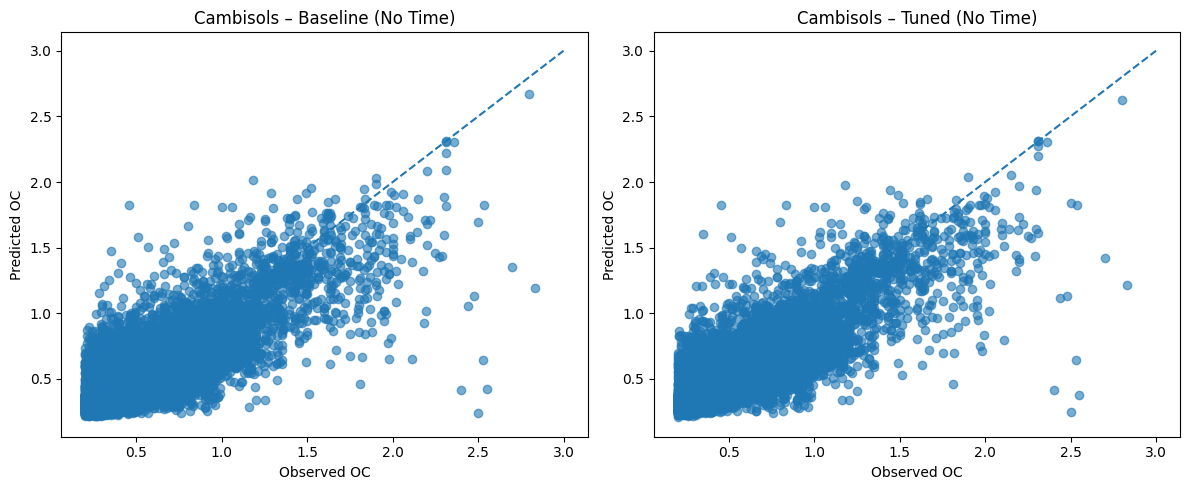


================ LUVISOLS =================


C:\Users\grs05\AppData\Local\Temp\ipykernel_9984\4004023028.py:31: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
C:\Users\grs05\AppData\Local\Temp\ipykernel_9984\4004023028.py:32: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["SAR_DATE"] = pd.to_datetime(df["SAR_DATE"], dayfirst=True, errors="coerce")



--- Baseline Performance (NO DOY / MONTH) ---
R2: 0.5740
RMSE: 0.1651
MAE: 0.1088
MAPE: 23.7721
Fitting 3 folds for each of 25 candidates, totalling 75 fits

--- Tuned Performance (NO DOY / MONTH) ---
R2: 0.6179
RMSE: 0.1564
MAE: 0.1027
MAPE: 22.2861

Best Hyperparameters:
{'n_estimators': 800, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 25}


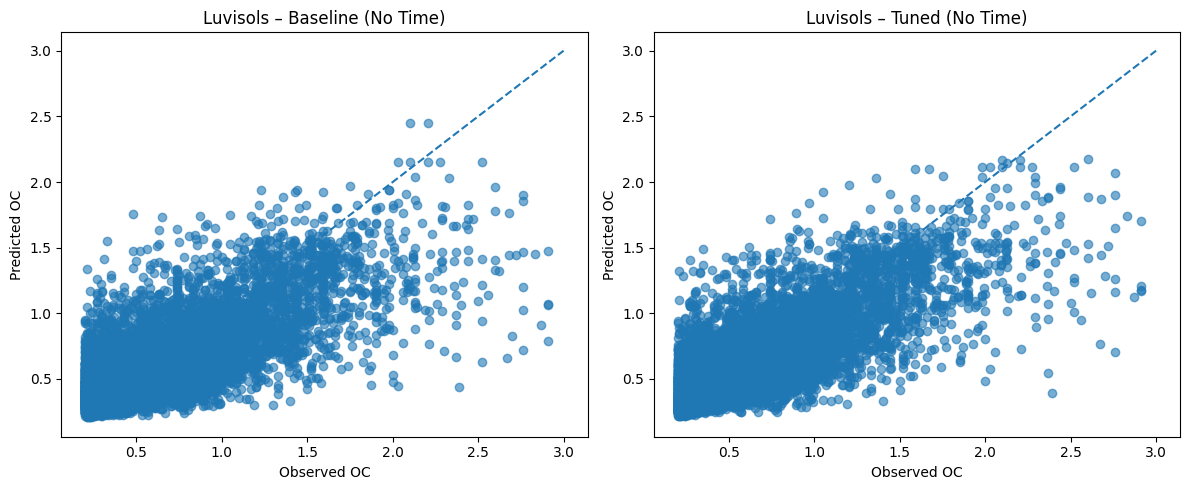


================ VERTISOLS =================


C:\Users\grs05\AppData\Local\Temp\ipykernel_9984\4004023028.py:31: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
C:\Users\grs05\AppData\Local\Temp\ipykernel_9984\4004023028.py:32: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["SAR_DATE"] = pd.to_datetime(df["SAR_DATE"], dayfirst=True, errors="coerce")



--- Baseline Performance (NO DOY / MONTH) ---
R2: 0.5191
RMSE: 0.2140
MAE: 0.1457
MAPE: 28.4565
Fitting 3 folds for each of 25 candidates, totalling 75 fits

--- Tuned Performance (NO DOY / MONTH) ---
R2: 0.5600
RMSE: 0.2047
MAE: 0.1387
MAPE: 26.8259

Best Hyperparameters:
{'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 25}


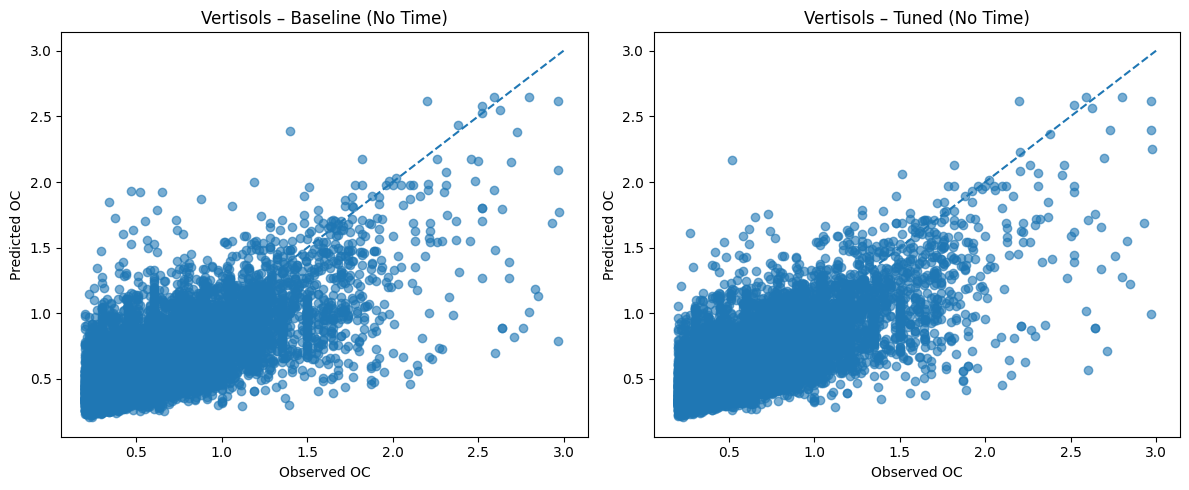


ALL SOIL MODELS (NO DOY / MONTH) TRAINED AND SAVED SUCCESSFULLY ✔


In [6]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ============================================================
# PATHS
# ============================================================
DATA_DIR = r"H:\Final Data"
MODEL_DIR = r"H:\Final Data\SOC Models"
os.makedirs(MODEL_DIR, exist_ok=True)

soil_files = [
    "India_SHC_Cambisols_Terrain_MERGED.csv",
    "India_SHC_Luvisols_Terrain_MERGED.csv",
    "India_SHC_Vertisols_Terrain_MERGED.csv"
]

# ============================================================
# FEATURE ENGINEERING
# ============================================================
def feature_engineering(df):
    eps = 1e-6

    # Dates
    df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
    df["SAR_DATE"] = pd.to_datetime(df["SAR_DATE"], dayfirst=True, errors="coerce")
    df["tile_date"] = pd.to_datetime(df["tile_date"], format="%Y%m%d", errors="coerce")

    # Vegetation
    df["NDVI"] = (df["B8"] - df["B4"]) / (df["B8"] + df["B4"] + eps)
    df["EVI"] = 2.5 * (df["B8"] - df["B4"]) / (df["B8"] + 6*df["B4"] - 7.5*df["B2"] + 1)
    df["SAVI"] = 1.5 * (df["B8"] - df["B4"]) / (df["B8"] + df["B4"] + 0.5)

    # Red-edge
    df["NDRE"] = (df["B8"] - df["B5"]) / (df["B8"] + df["B5"] + eps)
    df["CI_RE"] = (df["B8"] / (df["B5"] + eps)) - 1

    # Soil
    df["BSI"] = (
        (df["B11"] + df["B4"] - df["B8"] - df["B2"]) /
        (df["B11"] + df["B4"] + df["B8"] + df["B2"] + eps)
    )
    df["NDTI"] = (df["B11"] - df["B12"]) / (df["B11"] + df["B12"] + eps)
    df["BI"] = np.sqrt(df["B4"]**2 + df["B3"]**2)

    # Moisture
    df["NDWI"] = (df["B8"] - df["B11"]) / (df["B8"] + df["B11"] + eps)
    df["LSWI"] = (df["B8"] - df["B12"]) / (df["B8"] + df["B12"] + eps)

    # SAR
    df["VV_VH_ratio"] = df["VV"] / (df["VH"] + eps)
    df["VV_minus_VH"] = df["VV"] - df["VH"]
    df["log_VV"] = np.log(np.abs(df["VV"]) + 1)
    df["log_VH"] = np.log(np.abs(df["VH"]) + 1)

    # Terrain
    df["slope_norm"] = np.log1p(df["slope"])
    df["elev_range_90m"] = df["elev_max_90m"] - df["elev_min_90m"]

    # Temporal (ENGINEERED BUT NOT USED IN TRAINING)
    df["DOY"] = df["date"].dt.dayofyear
    df["month"] = df["date"].dt.month
    df["sar_optical_gap_days"] = (df["date"] - df["SAR_DATE"]).dt.days

    return df

# ============================================================
# METRICS
# ============================================================
def regression_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE": np.mean(np.abs((y_true - y_pred) / (y_true + 1e-6))) * 100
    }

# ============================================================
# TRAINING LOOP
# ============================================================
for file in soil_files:
    soil_name = file.split("_")[2]
    print(f"\n================ {soil_name.upper()} =================")

    df = pd.read_csv(os.path.join(DATA_DIR, file))
    df = feature_engineering(df)

    target = "OC"
    drop_cols = [
        "system:index", "tile_id", ".geo",
        "date", "SAR_DATE", "tile_date",
        "SOIL_CLASS", target
    ]

    X = df.drop(columns=drop_cols, errors="ignore")
    y = df[target]

    # --------------------------------------------------------
    # DROP UNWANTED + TEMPORAL ABLATION (DOY & MONTH)
    # --------------------------------------------------------
    X = X.drop(columns=[
        "Band_SCL",
        "cloud_cover",
        "days_from_survey",
        "sar_optical_gap_days",
        "DOY",
        "month"
    ], errors="ignore")

    # One-hot encode climate zone
    X = pd.get_dummies(X, columns=["CLIMATE_ZONE"], drop_first=True)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.10, random_state=42
    )

    # ========================================================
    # BASELINE MODEL
    # ========================================================
    rf_base = RandomForestRegressor(
        n_estimators=400,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42
    )

    rf_base.fit(X_train, y_train)
    y_pred_base = rf_base.predict(X_test)
    base_metrics = regression_metrics(y_test, y_pred_base)

    print("\n--- Baseline Performance (NO DOY / MONTH) ---")
    for k, v in base_metrics.items():
        print(f"{k}: {v:.4f}")

    joblib.dump(
        rf_base,
        os.path.join(MODEL_DIR, f"SOC_RF_{soil_name}_BASE_NO_TIME.pkl")
    )

    # ========================================================
    # HYPERPARAMETER TUNING
    # ========================================================
    param_grid = {
        "n_estimators": [300, 500, 800],
        "max_depth": [None, 15, 25, 40],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", 0.3, 0.5]
    }

    search = RandomizedSearchCV(
        RandomForestRegressor(n_jobs=-1, random_state=42),
        param_grid,
        n_iter=25,
        scoring="r2",
        cv=3,
        verbose=1
    )

    search.fit(X_train, y_train)
    rf_tuned = search.best_estimator_

    y_pred_tuned = rf_tuned.predict(X_test)
    tuned_metrics = regression_metrics(y_test, y_pred_tuned)

    print("\n--- Tuned Performance (NO DOY / MONTH) ---")
    for k, v in tuned_metrics.items():
        print(f"{k}: {v:.4f}")

    print("\nBest Hyperparameters:")
    print(search.best_params_)

    joblib.dump(
        rf_tuned,
        os.path.join(MODEL_DIR, f"SOC_RF_{soil_name}_TUNED_NO_TIME.pkl")
    )

    # ========================================================
    # PLOTS
    # ========================================================
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    ax[0].scatter(y_test, y_pred_base, alpha=0.6)
    ax[0].plot([y.min(), y.max()], [y.min(), y.max()], "--")
    ax[0].set_title(f"{soil_name} – Baseline (No Time)")

    ax[1].scatter(y_test, y_pred_tuned, alpha=0.6)
    ax[1].plot([y.min(), y.max()], [y.min(), y.max()], "--")
    ax[1].set_title(f"{soil_name} – Tuned (No Time)")

    for a in ax:
        a.set_xlabel("Observed OC")
        a.set_ylabel("Predicted OC")

    plt.tight_layout()
    plt.show()

print("\nALL SOIL MODELS (NO DOY / MONTH) TRAINED AND SAVED SUCCESSFULLY ✔")




# Also removed lat/lon


================ CAMBISOLS =================


C:\Users\grs05\AppData\Local\Temp\ipykernel_9984\4274271921.py:31: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
C:\Users\grs05\AppData\Local\Temp\ipykernel_9984\4274271921.py:32: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["SAR_DATE"] = pd.to_datetime(df["SAR_DATE"], dayfirst=True, errors="coerce")



--- Baseline Performance (NO TIME / NO COORD) ---
R2: 0.6256
RMSE: 0.1521
MAE: 0.1038
MAPE: 23.5291
Fitting 3 folds for each of 25 candidates, totalling 75 fits

--- Tuned Performance (NO TIME / NO COORD) ---
R2: 0.6534
RMSE: 0.1464
MAE: 0.1005
MAPE: 22.7114

Best Hyperparameters:
{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 25}


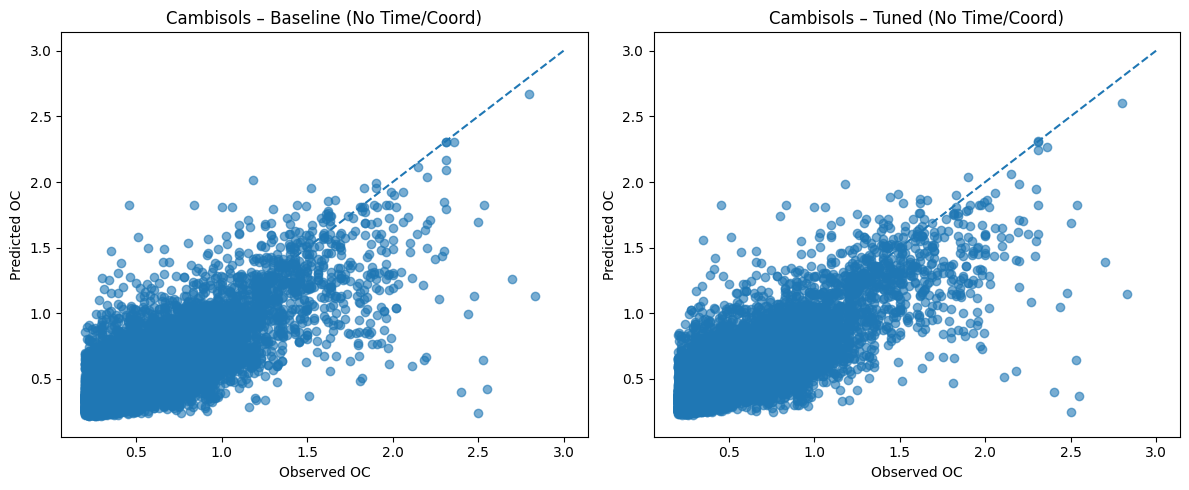


================ LUVISOLS =================


C:\Users\grs05\AppData\Local\Temp\ipykernel_9984\4274271921.py:31: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
C:\Users\grs05\AppData\Local\Temp\ipykernel_9984\4274271921.py:32: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["SAR_DATE"] = pd.to_datetime(df["SAR_DATE"], dayfirst=True, errors="coerce")



--- Baseline Performance (NO TIME / NO COORD) ---
R2: 0.4919
RMSE: 0.1803
MAE: 0.1192
MAPE: 26.2497
Fitting 3 folds for each of 25 candidates, totalling 75 fits

--- Tuned Performance (NO TIME / NO COORD) ---
R2: 0.5515
RMSE: 0.1694
MAE: 0.1113
MAPE: 24.3779

Best Hyperparameters:
{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 40}


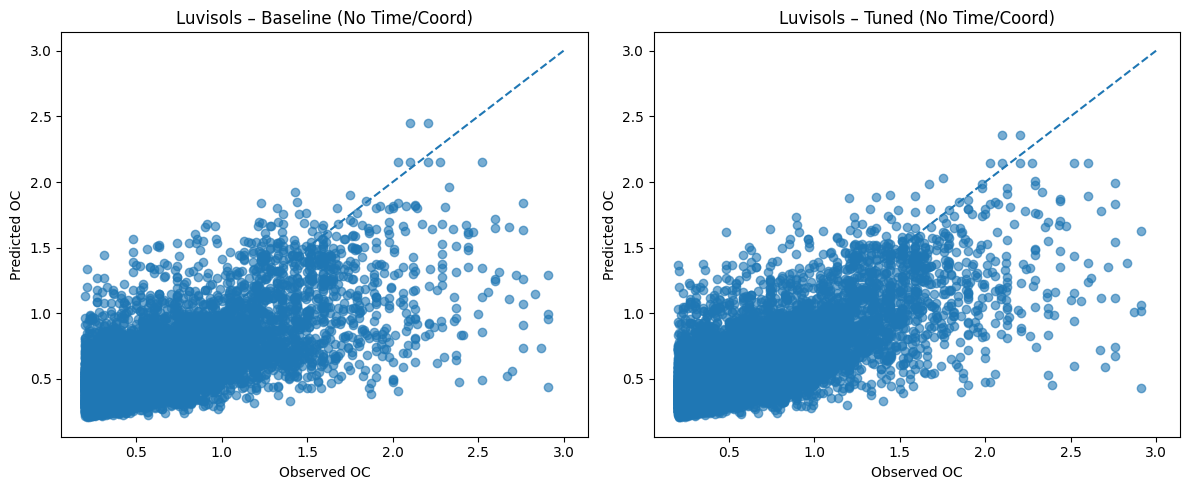


================ VERTISOLS =================

--- Tuned Performance (NO TIME / NO COORD) ---
R2: 0.4968
RMSE: 0.2189
MAE: 0.1503
MAPE: 29.4615

Best Hyperparameters:
{'n_estimators': 800, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': None}


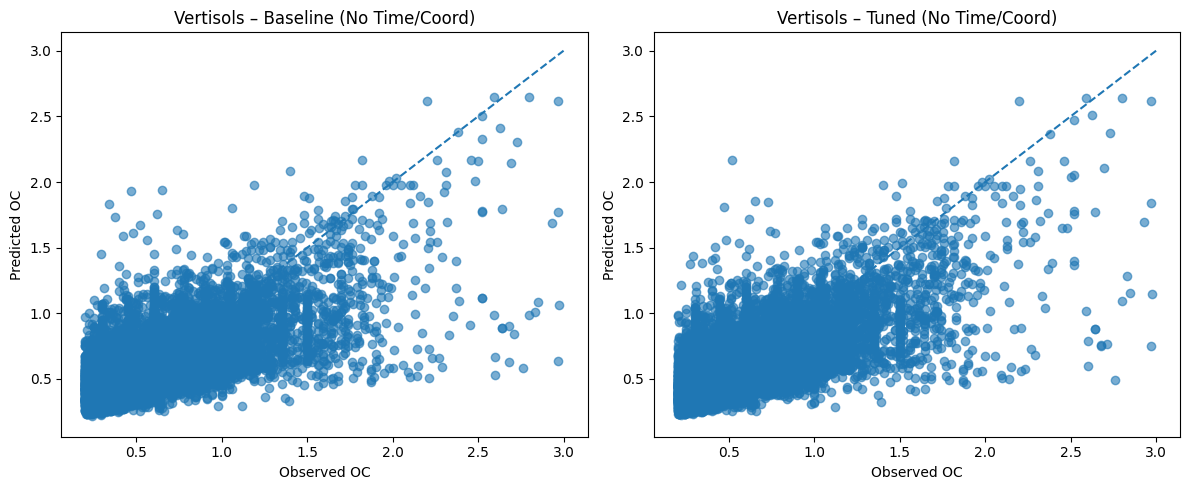


ALL SOIL MODELS (NO TIME / NO COORD) TRAINED AND SAVED SUCCESSFULLY ✔


In [7]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ============================================================
# PATHS
# ============================================================
DATA_DIR = r"H:\Final Data"
MODEL_DIR = r"H:\Final Data\SOC Models"
os.makedirs(MODEL_DIR, exist_ok=True)

soil_files = [
    "India_SHC_Cambisols_Terrain_MERGED.csv",
    "India_SHC_Luvisols_Terrain_MERGED.csv",
    "India_SHC_Vertisols_Terrain_MERGED.csv"
]

# ============================================================
# FEATURE ENGINEERING
# ============================================================
def feature_engineering(df):
    eps = 1e-6

    # Dates
    df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
    df["SAR_DATE"] = pd.to_datetime(df["SAR_DATE"], dayfirst=True, errors="coerce")
    df["tile_date"] = pd.to_datetime(df["tile_date"], format="%Y%m%d", errors="coerce")

    # Vegetation
    df["NDVI"] = (df["B8"] - df["B4"]) / (df["B8"] + df["B4"] + eps)
    df["EVI"] = 2.5 * (df["B8"] - df["B4"]) / (df["B8"] + 6*df["B4"] - 7.5*df["B2"] + 1)
    df["SAVI"] = 1.5 * (df["B8"] - df["B4"]) / (df["B8"] + df["B4"] + 0.5)

    # Red-edge
    df["NDRE"] = (df["B8"] - df["B5"]) / (df["B8"] + df["B5"] + eps)
    df["CI_RE"] = (df["B8"] / (df["B5"] + eps)) - 1

    # Soil
    df["BSI"] = (
        (df["B11"] + df["B4"] - df["B8"] - df["B2"]) /
        (df["B11"] + df["B4"] + df["B8"] + df["B2"] + eps)
    )
    df["NDTI"] = (df["B11"] - df["B12"]) / (df["B11"] + df["B12"] + eps)
    df["BI"] = np.sqrt(df["B4"]**2 + df["B3"]**2)

    # Moisture
    df["NDWI"] = (df["B8"] - df["B11"]) / (df["B8"] + df["B11"] + eps)
    df["LSWI"] = (df["B8"] - df["B12"]) / (df["B8"] + df["B12"] + eps)

    # SAR
    df["VV_VH_ratio"] = df["VV"] / (df["VH"] + eps)
    df["VV_minus_VH"] = df["VV"] - df["VH"]
    df["log_VV"] = np.log(np.abs(df["VV"]) + 1)
    df["log_VH"] = np.log(np.abs(df["VH"]) + 1)

    # Terrain
    df["slope_norm"] = np.log1p(df["slope"])
    df["elev_range_90m"] = df["elev_max_90m"] - df["elev_min_90m"]

    # Temporal (ENGINEERED BUT NOT USED)
    df["DOY"] = df["date"].dt.dayofyear
    df["month"] = df["date"].dt.month
    df["sar_optical_gap_days"] = (df["date"] - df["SAR_DATE"]).dt.days

    return df

# ============================================================
# METRICS
# ============================================================
def regression_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE": np.mean(np.abs((y_true - y_pred) / (y_true + 1e-6))) * 100
    }

# ============================================================
# TRAINING LOOP
# ============================================================
for file in soil_files:
    soil_name = file.split("_")[2]
    print(f"\n================ {soil_name.upper()} =================")

    df = pd.read_csv(os.path.join(DATA_DIR, file))
    df = feature_engineering(df)

    target = "OC"
    drop_cols = [
        "system:index", "tile_id", ".geo",
        "date", "SAR_DATE", "tile_date",
        "SOIL_CLASS", target
    ]

    X = df.drop(columns=drop_cols, errors="ignore")
    y = df[target]

    # --------------------------------------------------------
    # DROP UNWANTED + TEMPORAL + SPATIAL ABLATION
    # --------------------------------------------------------
    X = X.drop(columns=[
        "Band_SCL",
        "cloud_cover",
        "days_from_survey",
        "sar_optical_gap_days",
        "DOY",
        "month",
        "lat",
        "long"
    ], errors="ignore")

    # One-hot encode climate zone
    X = pd.get_dummies(X, columns=["CLIMATE_ZONE"], drop_first=True)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.10, random_state=42
    )

    # ========================================================
    # BASELINE MODEL
    # ========================================================
    rf_base = RandomForestRegressor(
        n_estimators=400,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42
    )

    rf_base.fit(X_train, y_train)
    y_pred_base = rf_base.predict(X_test)
    base_metrics = regression_metrics(y_test, y_pred_base)

    print("\n--- Baseline Performance (NO TIME / NO COORD) ---")
    for k, v in base_metrics.items():
        print(f"{k}: {v:.4f}")

    joblib.dump(
        rf_base,
        os.path.join(MODEL_DIR, f"SOC_RF_{soil_name}_BASE_NO_TIME_NO_COORD.pkl")
    )

    # ========================================================
    # HYPERPARAMETER TUNING
    # ========================================================
    param_grid = {
        "n_estimators": [300, 500, 800],
        "max_depth": [None, 15, 25, 40],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", 0.3, 0.5]
    }

    search = RandomizedSearchCV(
        RandomForestRegressor(n_jobs=-1, random_state=42),
        param_grid,
        n_iter=25,
        scoring="r2",
        cv=3,
        verbose=1
    )

    search.fit(X_train, y_train)
    rf_tuned = search.best_estimator_

    y_pred_tuned = rf_tuned.predict(X_test)
    tuned_metrics = regression_metrics(y_test, y_pred_tuned)

    print("\n--- Tuned Performance (NO TIME / NO COORD) ---")
    for k, v in tuned_metrics.items():
        print(f"{k}: {v:.4f}")

    print("\nBest Hyperparameters:")
    print(search.best_params_)

    joblib.dump(
        rf_tuned,
        os.path.join(MODEL_DIR, f"SOC_RF_{soil_name}_TUNED_NO_TIME_NO_COORD.pkl")
    )

    # ========================================================
    # PLOTS
    # ========================================================
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    ax[0].scatter(y_test, y_pred_base, alpha=0.6)
    ax[0].plot([y.min(), y.max()], [y.min(), y.max()], "--")
    ax[0].set_title(f"{soil_name} – Baseline (No Time/Coord)")

    ax[1].scatter(y_test, y_pred_tuned, alpha=0.6)
    ax[1].plot([y.min(), y.max()], [y.min(), y.max()], "--")
    ax[1].set_title(f"{soil_name} – Tuned (No Time/Coord)")

    for a in ax:
        a.set_xlabel("Observed OC")
        a.set_ylabel("Predicted OC")

    plt.tight_layout()
    plt.show()

print("\nALL SOIL MODELS (NO TIME / NO COORD) TRAINED AND SAVED SUCCESSFULLY ✔")




# Applied spatial CV

In [9]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ============================================================
# PATHS
# ============================================================
DATA_DIR = r"H:\Final Data"
MODEL_DIR = r"H:\Final Data\SOC Models"
os.makedirs(MODEL_DIR, exist_ok=True)

soil_files = [
    "India_SHC_Cambisols_Terrain_MERGED.csv",
    "India_SHC_Luvisols_Terrain_MERGED.csv",
    "India_SHC_Vertisols_Terrain_MERGED.csv"
]

# ============================================================
# FEATURE ENGINEERING
# ============================================================
def feature_engineering(df):
    eps = 1e-6

    df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
    df["SAR_DATE"] = pd.to_datetime(df["SAR_DATE"], dayfirst=True, errors="coerce")

    # Vegetation
    df["NDVI"] = (df["B8"] - df["B4"]) / (df["B8"] + df["B4"] + eps)
    df["EVI"] = 2.5 * (df["B8"] - df["B4"]) / (df["B8"] + 6*df["B4"] - 7.5*df["B2"] + 1)
    df["SAVI"] = 1.5 * (df["B8"] - df["B4"]) / (df["B8"] + df["B4"] + 0.5)

    # Red-edge
    df["NDRE"] = (df["B8"] - df["B5"]) / (df["B8"] + df["B5"] + eps)
    df["CI_RE"] = (df["B8"] / (df["B5"] + eps)) - 1

    # Soil
    df["BSI"] = (
        (df["B11"] + df["B4"] - df["B8"] - df["B2"]) /
        (df["B11"] + df["B4"] + df["B8"] + df["B2"] + eps)
    )
    df["NDTI"] = (df["B11"] - df["B12"]) / (df["B11"] + df["B12"] + eps)
    df["BI"] = np.sqrt(df["B4"]**2 + df["B3"]**2)

    # Moisture
    df["NDWI"] = (df["B8"] - df["B11"]) / (df["B8"] + df["B11"] + eps)
    df["LSWI"] = (df["B8"] - df["B12"]) / (df["B8"] + df["B12"] + eps)

    # SAR
    df["VV_VH_ratio"] = df["VV"] / (df["VH"] + eps)
    df["VV_minus_VH"] = df["VV"] - df["VH"]
    df["log_VV"] = np.log(np.abs(df["VV"]) + 1)
    df["log_VH"] = np.log(np.abs(df["VH"]) + 1)

    # Terrain
    df["slope_norm"] = np.log1p(df["slope"])
    df["elev_range_90m"] = df["elev_max_90m"] - df["elev_min_90m"]

    return df

# ============================================================
# METRICS
# ============================================================
def regression_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

# ============================================================
# SPATIAL CV LOOP
# ============================================================
for file in soil_files:
    soil_name = file.split("_")[2]
    print(f"\n================ {soil_name.upper()} (SPATIAL CV) =================")

    df = pd.read_csv(os.path.join(DATA_DIR, file))
    df = feature_engineering(df)

    target = "OC"
    groups = df["tile_id"]

    drop_cols = [
        "system:index", ".geo",
        "date", "SAR_DATE", "tile_date",
        "SOIL_CLASS", "tile_id", target,
        "Band_SCL", "cloud_cover",
        "days_from_survey", "lat", "long"
    ]

    X = df.drop(columns=drop_cols, errors="ignore")
    y = df[target]

    # One-hot climate
    X = pd.get_dummies(X, columns=["CLIMATE_ZONE"], drop_first=True)

    # ========================================================
    # SPATIAL CROSS-VALIDATION
    # ========================================================
    gkf = GroupKFold(n_splits=5)

    r2s, rmses, maes = [], [], []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = RandomForestRegressor(
            n_estimators=600,
            max_features=0.5,
            min_samples_leaf=4,
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        m = regression_metrics(y_test, preds)
        r2s.append(m["R2"])
        rmses.append(m["RMSE"])
        maes.append(m["MAE"])

        print(f"Fold {fold+1} → R2={m['R2']:.3f}, RMSE={m['RMSE']:.3f}")

    print("\n--- SPATIAL CV SUMMARY ---")
    print(f"Mean R2   : {np.mean(r2s):.3f}")
    print(f"Mean RMSE: {np.mean(rmses):.3f}")
    print(f"Mean MAE : {np.mean(maes):.3f}")

    # ========================================================
    # TRAIN FINAL MODEL ON ALL DATA
    # ========================================================
    final_model = RandomForestRegressor(
        n_estimators=600,
        max_features=0.5,
        min_samples_leaf=4,
        random_state=42,
        n_jobs=-1
    )

    final_model.fit(X, y)

    joblib.dump(
        final_model,
        os.path.join(MODEL_DIR, f"SOC_RF_{soil_name}_SPATIAL_CV_FINAL.pkl")
    )

print("\nSPATIAL CV COMPLETE — MODELS SAVED ✔")





================ CAMBISOLS (SPATIAL CV) =================


C:\Users\grs05\AppData\Local\Temp\ipykernel_9984\2972502404.py:30: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
C:\Users\grs05\AppData\Local\Temp\ipykernel_9984\2972502404.py:31: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["SAR_DATE"] = pd.to_datetime(df["SAR_DATE"], dayfirst=True, errors="coerce")


Fold 1 → R2=0.461, RMSE=0.190
Fold 2 → R2=0.460, RMSE=0.186
Fold 3 → R2=0.446, RMSE=0.176
Fold 4 → R2=0.386, RMSE=0.177
Fold 5 → R2=0.446, RMSE=0.190

--- SPATIAL CV SUMMARY ---
Mean R2   : 0.440
Mean RMSE: 0.184
Mean MAE : 0.126

================ LUVISOLS (SPATIAL CV) =================


C:\Users\grs05\AppData\Local\Temp\ipykernel_9984\2972502404.py:30: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
C:\Users\grs05\AppData\Local\Temp\ipykernel_9984\2972502404.py:31: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["SAR_DATE"] = pd.to_datetime(df["SAR_DATE"], dayfirst=True, errors="coerce")


Fold 1 → R2=0.185, RMSE=0.240
Fold 2 → R2=0.252, RMSE=0.233
Fold 3 → R2=0.211, RMSE=0.210
Fold 4 → R2=0.256, RMSE=0.208
Fold 5 → R2=0.197, RMSE=0.216

--- SPATIAL CV SUMMARY ---
Mean R2   : 0.220
Mean RMSE: 0.221
Mean MAE : 0.146

================ VERTISOLS (SPATIAL CV) =================


C:\Users\grs05\AppData\Local\Temp\ipykernel_9984\2972502404.py:30: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
C:\Users\grs05\AppData\Local\Temp\ipykernel_9984\2972502404.py:31: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["SAR_DATE"] = pd.to_datetime(df["SAR_DATE"], dayfirst=True, errors="coerce")


Fold 1 → R2=0.217, RMSE=0.295
Fold 2 → R2=0.151, RMSE=0.292
Fold 3 → R2=0.141, RMSE=0.257
Fold 4 → R2=0.185, RMSE=0.262
Fold 5 → R2=0.218, RMSE=0.293

--- SPATIAL CV SUMMARY ---
Mean R2   : 0.182
Mean RMSE: 0.280
Mean MAE : 0.198

SPATIAL CV COMPLETE — MODELS SAVED ✔


In [11]:
import os
import joblib
import pandas as pd
import numpy as np

from collections import defaultdict
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance

# ============================================================
# PATHS
# ============================================================
DATA_DIR = r"H:\Final Data"
MODEL_DIR = r"H:\Final Data\SOC Models"
os.makedirs(MODEL_DIR, exist_ok=True)

soil_files = [
    "India_SHC_Cambisols_Terrain_MERGED.csv",
    "India_SHC_Luvisols_Terrain_MERGED.csv",
    "India_SHC_Vertisols_Terrain_MERGED.csv"
]

# ============================================================
# FEATURE ENGINEERING
# ============================================================
def feature_engineering(df):
    eps = 1e-6

    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["SAR_DATE"] = pd.to_datetime(df["SAR_DATE"], errors="coerce")

    # Vegetation
    df["NDVI"] = (df["B8"] - df["B4"]) / (df["B8"] + df["B4"] + eps)
    df["EVI"] = 2.5 * (df["B8"] - df["B4"]) / (df["B8"] + 6*df["B4"] - 7.5*df["B2"] + 1)
    df["SAVI"] = 1.5 * (df["B8"] - df["B4"]) / (df["B8"] + df["B4"] + 0.5)

    # Red-edge
    df["NDRE"] = (df["B8"] - df["B5"]) / (df["B8"] + df["B5"] + eps)
    df["CI_RE"] = (df["B8"] / (df["B5"] + eps)) - 1

    # Soil
    df["BSI"] = (
        (df["B11"] + df["B4"] - df["B8"] - df["B2"]) /
        (df["B11"] + df["B4"] + df["B8"] + df["B2"] + eps)
    )
    df["NDTI"] = (df["B11"] - df["B12"]) / (df["B11"] + df["B12"] + eps)
    df["BI"] = np.sqrt(df["B4"]**2 + df["B3"]**2)

    # Moisture
    df["NDWI"] = (df["B8"] - df["B11"]) / (df["B8"] + df["B11"] + eps)
    df["LSWI"] = (df["B8"] - df["B12"]) / (df["B8"] + df["B12"] + eps)

    # SAR
    df["VV_VH_ratio"] = df["VV"] / (df["VH"] + eps)
    df["VV_minus_VH"] = df["VV"] - df["VH"]
    df["log_VV"] = np.log(np.abs(df["VV"]) + 1)
    df["log_VH"] = np.log(np.abs(df["VH"]) + 1)

    # Terrain
    df["slope_norm"] = np.log1p(df["slope"])
    df["elev_range_90m"] = df["elev_max_90m"] - df["elev_min_90m"]

    return df

# ============================================================
# METRICS
# ============================================================
def regression_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

# ============================================================
# MAIN LOOP — ALL SOILS
# ============================================================
for file in soil_files:

    soil_name = file.split("_")[2]
    print(f"\n================ {soil_name.upper()} =================")

    # --------------------------------------------------------
    # LOAD & PREP
    # --------------------------------------------------------
    df = pd.read_csv(os.path.join(DATA_DIR, file))
    df = feature_engineering(df)

    target = "OC"
    groups = df["tile_id"]

    drop_cols = [
        "system:index", ".geo",
        "date", "SAR_DATE", "tile_date",
        "SOIL_CLASS", "tile_id", target,
        "Band_SCL", "cloud_cover",
        "days_from_survey", "lat", "long"
    ]

    X = df.drop(columns=drop_cols, errors="ignore")
    y = df[target]

    X = pd.get_dummies(X, columns=["CLIMATE_ZONE"], drop_first=True)

    # --------------------------------------------------------
    # STEP 1: SPATIAL PERMUTATION IMPORTANCE
    # --------------------------------------------------------
    gkf = GroupKFold(n_splits=5)
    feature_importance = defaultdict(list)

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
        print(f"Permutation importance — Fold {fold+1}")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = RandomForestRegressor(
            n_estimators=600,
            max_features=0.5,
            min_samples_leaf=4,
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_train, y_train)

        result = permutation_importance(
            model,
            X_test,
            y_test,
            n_repeats=10,
            random_state=42,
            scoring="r2",
            n_jobs=-1
        )

        for i, col in enumerate(X.columns):
            feature_importance[col].append(result.importances_mean[i])

    # --------------------------------------------------------
    # STEP 2: AGGREGATE & SELECT FEATURES
    # --------------------------------------------------------
    imp_df = (
        pd.DataFrame(feature_importance)
        .T
        .rename(columns=lambda x: f"fold_{x+1}")
    )

    imp_df["mean_importance"] = imp_df.mean(axis=1)
    imp_df["std_importance"] = imp_df.std(axis=1)
    imp_df = imp_df.sort_values("mean_importance", ascending=False)

    selected_features = imp_df[
        imp_df["mean_importance"] > 0
    ].index.tolist()

    print("\nFinal selected features:")
    for f in selected_features:
        print(f"  • {f}")

    print(f"\nSelected {len(selected_features)} / {X.shape[1]} features")

    # --------------------------------------------------------
    # STEP 3: SPATIAL CV WITH SELECTED FEATURES
    # --------------------------------------------------------
    X_sel = X[selected_features]

    r2s, rmses, maes = [], [], []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X_sel, y, groups)):
        X_train, X_test = X_sel.iloc[train_idx], X_sel.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = RandomForestRegressor(
            n_estimators=600,
            max_features=0.5,
            min_samples_leaf=4,
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        m = regression_metrics(y_test, preds)
        r2s.append(m["R2"])
        rmses.append(m["RMSE"])
        maes.append(m["MAE"])

        print(f"Fold {fold+1} → R2={m['R2']:.3f}, RMSE={m['RMSE']:.3f}")

    print("\n--- FEATURE-SELECTED SPATIAL CV SUMMARY ---")
    print(f"Mean R2   : {np.mean(r2s):.3f}")
    print(f"Mean RMSE: {np.mean(rmses):.3f}")
    print(f"Mean MAE : {np.mean(maes):.3f}")

    # --------------------------------------------------------
    # STEP 4: TRAIN FINAL MODEL & SAVE
    # --------------------------------------------------------
    final_model = RandomForestRegressor(
        n_estimators=600,
        max_features=0.5,
        min_samples_leaf=4,
        random_state=42,
        n_jobs=-1
    )

    final_model.fit(X_sel, y)

    joblib.dump(
        {
            "model": final_model,
            "features": selected_features,
            "importance": imp_df
        },
        os.path.join(
            MODEL_DIR,
            f"SOC_RF_{soil_name}_SPATIAL_FS_FINAL.pkl"
        )
    )

    print(f"\n{soil_name.upper()} MODEL SAVED ✔")

print("\nALL SOILS — SPATIAL FEATURE SELECTION COMPLETE ✔✔")



================ CAMBISOLS =================
Permutation importance — Fold 1
Permutation importance — Fold 2
Permutation importance — Fold 3


C:\Users\grs05\anaconda3\envs\manisha\lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Permutation importance — Fold 4
Permutation importance — Fold 5

Final selected features:
  • R_factor
  • elev_max_90m
  • CLIMATE_ZONE_Tropical
  • elev_mean_90m
  • elev_min_90m
  • CLIMATE_ZONE_Temperate
  • elevation
  • B11
  • NDTI
  • B6
  • NDWI
  • BSI
  • TPI_600m
  • elev_std_90m
  • B12
  • LSWI
  • B7
  • NDRE
  • B8
  • aspect_cos
  • aspect_sin
  • B5
  • CI_RE
  • CLIMATE_ZONE_Cold
  • elev_range_90m
  • B8A
  • log_flow_acc
  • TPI_300m
  • log_VH
  • SPI
  • VH

Selected 31 / 48 features
Fold 1 → R2=0.462, RMSE=0.190
Fold 2 → R2=0.464, RMSE=0.186
Fold 3 → R2=0.447, RMSE=0.176
Fold 4 → R2=0.396, RMSE=0.175
Fold 5 → R2=0.453, RMSE=0.189

--- FEATURE-SELECTED SPATIAL CV SUMMARY ---
Mean R2   : 0.444
Mean RMSE: 0.183
Mean MAE : 0.125

CAMBISOLS MODEL SAVED ✔

================ LUVISOLS =================
Permutation importance — Fold 1
Permutation importance — Fold 2


C:\Users\grs05\anaconda3\envs\manisha\lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Permutation importance — Fold 3
Permutation importance — Fold 4
Permutation importance — Fold 5

Final selected features:
  • R_factor
  • elev_mean_90m
  • CLIMATE_ZONE_Temperate
  • elev_max_90m
  • CLIMATE_ZONE_Tropical
  • elev_min_90m
  • elevation
  • B11
  • NDWI
  • NDTI
  • BSI
  • log_flow_acc
  • B8A
  • B6
  • B7
  • B2
  • elev_std_90m
  • B12
  • TPI_600m
  • SAVI
  • B5
  • TPI_300m
  • B8
  • aspect_cos
  • elev_range_90m
  • plan_curvature
  • LSWI
  • aspect_sin
  • NDVI
  • EVI
  • profile_curvature
  • slope

Selected 32 / 47 features
Fold 1 → R2=0.183, RMSE=0.240
Fold 2 → R2=0.256, RMSE=0.232
Fold 3 → R2=0.213, RMSE=0.209
Fold 4 → R2=0.263, RMSE=0.208
Fold 5 → R2=0.199, RMSE=0.216

--- FEATURE-SELECTED SPATIAL CV SUMMARY ---
Mean R2   : 0.223
Mean RMSE: 0.221
Mean MAE : 0.146

LUVISOLS MODEL SAVED ✔

================ VERTISOLS =================


C:\Users\grs05\AppData\Local\Temp\ipykernel_9984\2789104117.py:31: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"], errors="coerce")
C:\Users\grs05\AppData\Local\Temp\ipykernel_9984\2789104117.py:32: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["SAR_DATE"] = pd.to_datetime(df["SAR_DATE"], errors="coerce")


Permutation importance — Fold 1
Permutation importance — Fold 2
Permutation importance — Fold 3
Permutation importance — Fold 4
Permutation importance — Fold 5

Final selected features:
  • R_factor
  • elev_mean_90m
  • elev_max_90m
  • elev_min_90m
  • CLIMATE_ZONE_Tropical
  • CLIMATE_ZONE_Temperate
  • elevation
  • B11
  • B12
  • log_flow_acc
  • B6
  • TPI_600m
  • NDTI
  • NDWI
  • aspect_sin
  • aspect_cos
  • B2
  • plan_curvature

Selected 18 / 47 features
Fold 1 → R2=0.229, RMSE=0.292
Fold 2 → R2=0.157, RMSE=0.291
Fold 3 → R2=0.149, RMSE=0.256
Fold 4 → R2=0.195, RMSE=0.260
Fold 5 → R2=0.215, RMSE=0.293

--- FEATURE-SELECTED SPATIAL CV SUMMARY ---
Mean R2   : 0.189
Mean RMSE: 0.279
Mean MAE : 0.196

VERTISOLS MODEL SAVED ✔

ALL SOILS — SPATIAL FEATURE SELECTION COMPLETE ✔✔


# Final Code with Feature selection, Encoder, Model Saved

In [16]:
import os
import joblib
import pandas as pd
import numpy as np

from collections import defaultdict
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import OneHotEncoder
from joblib import parallel_backend

# ============================================================
# PATHS
# ============================================================
DATA_DIR  = r"H:\Final Data"
MODEL_DIR = r"H:\Final Data\SOC Models"
os.makedirs(MODEL_DIR, exist_ok=True)

# IMPORTANT: put joblib temp on a drive with space (NOT C:)
JOBLIB_TMP = r"H:\joblib_tmp"
os.makedirs(JOBLIB_TMP, exist_ok=True)
os.environ["JOBLIB_TEMP_FOLDER"] = JOBLIB_TMP  # joblib respects this

soil_files = [
    "India_SHC_Cambisols_Terrain_MERGED.csv",
    "India_SHC_Luvisols_Terrain_MERGED.csv",
    "India_SHC_Vertisols_Terrain_MERGED.csv"
]

# ============================================================
# FIXED CLIMATE ZONES (KNOWN A-PRIORI)
# ============================================================
CLIMATE_ZONES = ["Tropical", "Arid", "Temperate", "Cold", "Polar"]

# ============================================================
# FEATURE ENGINEERING
# ============================================================
def feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    eps = 1e-6

    df["date"] = pd.to_datetime(df.get("date"), errors="coerce")
    df["SAR_DATE"] = pd.to_datetime(df.get("SAR_DATE"), errors="coerce")

    # Vegetation
    df["NDVI"] = (df["B8"] - df["B4"]) / (df["B8"] + df["B4"] + eps)
    df["EVI"]  = 2.5 * (df["B8"] - df["B4"]) / (df["B8"] + 6*df["B4"] - 7.5*df["B2"] + 1)
    df["SAVI"] = 1.5 * (df["B8"] - df["B4"]) / (df["B8"] + df["B4"] + 0.5)

    # Red-edge
    df["NDRE"]  = (df["B8"] - df["B5"]) / (df["B8"] + df["B5"] + eps)
    df["CI_RE"] = (df["B8"] / (df["B5"] + eps)) - 1

    # Soil
    df["BSI"] = (
        (df["B11"] + df["B4"] - df["B8"] - df["B2"]) /
        (df["B11"] + df["B4"] + df["B8"] + df["B2"] + eps)
    )
    df["NDTI"] = (df["B11"] - df["B12"]) / (df["B11"] + df["B12"] + eps)
    df["BI"]   = np.sqrt(df["B4"]**2 + df["B3"]**2)

    # Moisture
    df["NDWI"] = (df["B8"] - df["B11"]) / (df["B8"] + df["B11"] + eps)
    df["LSWI"] = (df["B8"] - df["B12"]) / (df["B8"] + df["B12"] + eps)

    # SAR
    df["VV_VH_ratio"] = df["VV"] / (df["VH"] + eps)
    df["VV_minus_VH"] = df["VV"] - df["VH"]
    df["log_VV"]      = np.log(np.abs(df["VV"]) + 1)
    df["log_VH"]      = np.log(np.abs(df["VH"]) + 1)

    # Terrain
    df["slope_norm"]      = np.log1p(df["slope"])
    df["elev_range_90m"]  = df["elev_max_90m"] - df["elev_min_90m"]

    return df

# ============================================================
# METRICS
# ============================================================
def regression_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred))
    }

# ============================================================
# RF FACTORY (keep one place to tune)
# ============================================================
def make_rf():
    return RandomForestRegressor(
        n_estimators=600,
        max_features=0.5,
        min_samples_leaf=4,
        random_state=42,
        n_jobs=-1  # OK here; we will NOT parallelize permutation_importance with processes
    )

# ============================================================
# MAIN LOOP — ALL SOILS
# ============================================================
for file in soil_files:

    soil_name = file.split("_")[2]
    print(f"\n================ {soil_name.upper()} =================")

    # --------------------------------------------------------
    # LOAD + FEATURE ENGINEERING
    # --------------------------------------------------------
    df = pd.read_csv(os.path.join(DATA_DIR, file))
    df = feature_engineering(df)

    target = "OC"
    groups = df["tile_id"]

    drop_cols = [
        "system:index", ".geo",
        "date", "SAR_DATE", "tile_date",
        "SOIL_CLASS", "tile_id", target,
        "Band_SCL", "cloud_cover",
        "days_from_survey", "lat", "long"
    ]

    X = df.drop(columns=drop_cols, errors="ignore")
    y = df[target].astype(float)

    # --------------------------------------------------------
    # ONE-HOT ENCODER (DEPLOYMENT SAFE)
    # --------------------------------------------------------
    cat_cols = ["CLIMATE_ZONE"]
    for c in cat_cols:
        if c not in X.columns:
            X[c] = np.nan  # ensure exists

    num_cols = X.columns.difference(cat_cols)

    encoder = OneHotEncoder(
        categories=[CLIMATE_ZONES],
        handle_unknown="ignore",
        sparse_output=False
    )

    X_cat = encoder.fit_transform(X[cat_cols])
    cat_feature_names = encoder.get_feature_names_out(cat_cols)

    X_enc = pd.DataFrame(X_cat, columns=cat_feature_names, index=X.index)

    X_final = pd.concat([X[num_cols], X_enc], axis=1)

    # Reduce memory pressure (often helps a lot)
    X_final = X_final.apply(pd.to_numeric, errors="coerce").astype(np.float32)
    y = y.astype(np.float32)

    # --------------------------------------------------------
    # SPATIAL PERMUTATION IMPORTANCE
    #   FIX: avoid loky multiprocess temp-memmap explosion
    #   - use threading backend OR single-thread (n_jobs=1)
    #   - also set max_samples to limit work & memory
    # --------------------------------------------------------
    gkf = GroupKFold(n_splits=5)
    feature_importance = defaultdict(list)

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X_final, y, groups)):
        print(f"Permutation importance — Fold {fold+1}")

        model = make_rf()
        model.fit(X_final.iloc[train_idx], y.iloc[train_idx])

        # Use THREADING backend so it doesn't pickle/memmap huge arrays to disk.
        # Also keep permutation_importance n_jobs=1 (safest + predictable).
        with parallel_backend("threading"):
            result = permutation_importance(
                model,
                X_final.iloc[test_idx],
                y.iloc[test_idx],
                n_repeats=5,          # was 10; reduce to cut compute + temp usage
                scoring="r2",
                random_state=42,
                n_jobs=1,             # IMPORTANT: prevents loky process spawning
                max_samples=0.7       # subsample for stability + speed (optional)
            )

        for i, col in enumerate(X_final.columns):
            feature_importance[col].append(float(result.importances_mean[i]))

    imp_df = pd.DataFrame(feature_importance).T
    imp_df["mean_importance"] = imp_df.mean(axis=1)
    imp_df = imp_df.sort_values("mean_importance", ascending=False)

    # Keep positive-importance features; you can change threshold (e.g. > 0.001)
    selected_features = imp_df[imp_df["mean_importance"] > 0].index.tolist()

    print(f"Selected {len(selected_features)} / {X_final.shape[1]} features")

    # --------------------------------------------------------
    # SPATIAL CV WITH SELECTED FEATURES
    # --------------------------------------------------------
    X_sel = X_final[selected_features]

    r2s, rmses, maes = [], [], []

    for train_idx, test_idx in gkf.split(X_sel, y, groups):
        model = make_rf()
        model.fit(X_sel.iloc[train_idx], y.iloc[train_idx])
        preds = model.predict(X_sel.iloc[test_idx])

        m = regression_metrics(y.iloc[test_idx], preds)
        r2s.append(m["R2"])
        rmses.append(m["RMSE"])
        maes.append(m["MAE"])

    metrics_summary = {
        "R2_mean": float(np.mean(r2s)),
        "RMSE_mean": float(np.mean(rmses)),
        "MAE_mean": float(np.mean(maes))
    }

    print(metrics_summary)

    # --------------------------------------------------------
    # FINAL TRAINING + SAVE DEPLOYMENT OBJECT
    # --------------------------------------------------------
    final_model = make_rf()
    final_model.fit(X_sel, y)

    deployment_object = {
        "model": final_model,
        "encoder": encoder,
        "features": selected_features,          # final predictors (ORDERED)
        "numeric_features": list(num_cols),
        "categorical_features": cat_cols,
        "target": target,
        "soil_type": soil_name,
        "training_metrics": metrics_summary,
        "climate_zones": CLIMATE_ZONES
    }

    out_path = os.path.join(MODEL_DIR, f"SOC_RF_{soil_name}_DEPLOYMENT.pkl")
    joblib.dump(deployment_object, out_path)
    print(f"{soil_name.upper()} MODEL + ENCODER SAVED ✔  -> {out_path}")

print("\nALL SOIL MODELS TRAINED — DEPLOYMENT READY ✔✔")



================ CAMBISOLS =================
Permutation importance — Fold 1
Permutation importance — Fold 2
Permutation importance — Fold 3
Permutation importance — Fold 4
Permutation importance — Fold 5
Selected 49 / 50 features
{'R2_mean': 0.4416946840989846, 'RMSE_mean': 0.18357762254800794, 'MAE_mean': 0.1259499036014869}
CAMBISOLS MODEL + ENCODER SAVED ✔  -> H:\Final Data\SOC Models\SOC_RF_Cambisols_DEPLOYMENT.pkl

================ LUVISOLS =================
Permutation importance — Fold 1
Permutation importance — Fold 2
Permutation importance — Fold 3
Permutation importance — Fold 4
Permutation importance — Fold 5
Selected 24 / 50 features
{'R2_mean': 0.22870986556310066, 'RMSE_mean': 0.22004784228467686, 'MAE_mean': 0.14492328542300895}
LUVISOLS MODEL + ENCODER SAVED ✔  -> H:\Final Data\SOC Models\SOC_RF_Luvisols_DEPLOYMENT.pkl

================ VERTISOLS =================


C:\Users\grs05\AppData\Local\Temp\ipykernel_9984\2818842127.py:43: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df.get("date"), errors="coerce")
C:\Users\grs05\AppData\Local\Temp\ipykernel_9984\2818842127.py:44: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["SAR_DATE"] = pd.to_datetime(df.get("SAR_DATE"), errors="coerce")


Permutation importance — Fold 1
Permutation importance — Fold 2
Permutation importance — Fold 3
Permutation importance — Fold 4
Permutation importance — Fold 5
Selected 10 / 50 features
{'R2_mean': 0.18038982087235886, 'RMSE_mean': 0.28020799102021693, 'MAE_mean': 0.19605609277300204}
VERTISOLS MODEL + ENCODER SAVED ✔  -> H:\Final Data\SOC Models\SOC_RF_Vertisols_DEPLOYMENT.pkl

ALL SOIL MODELS TRAINED — DEPLOYMENT READY ✔✔


# Loading Trained Model and Predicting

In [17]:
import pandas as pd
import numpy as np
import joblib
import os

# ============================================================
# PATHS
# ============================================================
MODEL_PATH = r"H:\Final Data\SOC Models\SOC_RF_Vertisols_DEPLOYMENT.pkl"
INPUT_CSV  = r"C:\Users\grs05\Downloads\April2025_S1_S2_DEM_CHIRPS_Rfactor_FULL_10m2.csv"
OUTPUT_CSV = r"H:\Final Data\April2025_OC_Predictions_RF_Vertisols.csv"

# ============================================================
# LOAD DEPLOYMENT OBJECT
# ============================================================
obj = joblib.load(MODEL_PATH)

model               = obj["model"]
encoder             = obj["encoder"]
selected_features   = obj["features"]
num_cols            = obj["numeric_features"]
cat_cols            = obj["categorical_features"]
climate_zones       = obj["climate_zones"]

print("✅ Deployment model loaded")
print(f"Using {len(selected_features)} features")

# ============================================================
# FEATURE ENGINEERING (MUST MATCH TRAINING EXACTLY)
# ============================================================
def feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    eps = 1e-6

    # Vegetation
    df["NDVI"] = (df["B8"] - df["B4"]) / (df["B8"] + df["B4"] + eps)
    df["EVI"]  = 2.5 * (df["B8"] - df["B4"]) / (df["B8"] + 6*df["B4"] - 7.5*df["B2"] + 1)
    df["SAVI"] = 1.5 * (df["B8"] - df["B4"]) / (df["B8"] + df["B4"] + 0.5)

    # Red-edge
    df["NDRE"]  = (df["B8"] - df["B5"]) / (df["B8"] + df["B5"] + eps)
    df["CI_RE"] = (df["B8"] / (df["B5"] + eps)) - 1

    # Soil
    df["BSI"] = (
        (df["B11"] + df["B4"] - df["B8"] - df["B2"]) /
        (df["B11"] + df["B4"] + df["B8"] + df["B2"] + eps)
    )
    df["NDTI"] = (df["B11"] - df["B12"]) / (df["B11"] + df["B12"] + eps)
    df["BI"]   = np.sqrt(df["B4"]**2 + df["B3"]**2)

    # Moisture
    df["NDWI"] = (df["B8"] - df["B11"]) / (df["B8"] + df["B11"] + eps)
    df["LSWI"] = (df["B8"] - df["B12"]) / (df["B8"] + df["B12"] + eps)

    # SAR
    df["VV_VH_ratio"] = df["VV"] / (df["VH"] + eps)
    df["VV_minus_VH"] = df["VV"] - df["VH"]
    df["log_VV"]      = np.log(np.abs(df["VV"]) + 1)
    df["log_VH"]      = np.log(np.abs(df["VH"]) + 1)

    # Terrain
    df["slope_norm"]     = np.log1p(df["slope"])
    df["elev_range_90m"] = df["elev_max_90m"] - df["elev_min_90m"]

    return df

# ============================================================
# LOAD INPUT DATA
# ============================================================
df = pd.read_csv(INPUT_CSV)
print("📥 Input data shape:", df.shape)

df = feature_engineering(df)

# ============================================================
# CLIMATE ZONE (VERTISOLS CASE)
# ============================================================
# If your deployment area is known to be Vertisols + Arid:
df["CLIMATE_ZONE"] = "Arid"

# Ensure categorical column exists
for c in cat_cols:
    if c not in df.columns:
        df[c] = np.nan

# ============================================================
# BUILD NUMERIC + CATEGORICAL MATRICES
# ============================================================
# Ensure all numeric columns used during training exist
for c in num_cols:
    if c not in df.columns:
        df[c] = 0.0

X_num = df[num_cols]

# Encode categorical features using SAVED encoder
X_cat = encoder.transform(df[cat_cols])
X_cat = pd.DataFrame(
    X_cat,
    columns=encoder.get_feature_names_out(cat_cols),
    index=df.index
)

# Combine
X_full = pd.concat([X_num, X_cat], axis=1)

# Keep ONLY selected features (correct order)
X_final = X_full.reindex(columns=selected_features, fill_value=0.0)

# Type safety
X_final = X_final.astype(np.float32)

print("🧮 Final feature matrix:", X_final.shape)

# ============================================================
# PREDICT SOC
# ============================================================
df["Predicted_OC"] = model.predict(X_final)
print("🎯 Prediction completed")

# ============================================================
# SAVE OUTPUT
# ============================================================
df.to_csv(OUTPUT_CSV, index=False)
print("💾 Output saved to:")
print(OUTPUT_CSV)



✅ Deployment model loaded
Using 10 features
📥 Input data shape: (2395, 33)
🧮 Final feature matrix: (2395, 10)
🎯 Prediction completed
💾 Output saved to:
H:\Final Data\April2025_OC_Predictions_RF_Vertisols.csv


In [19]:
pip install contextily


   ---------------------------------------- 2/2 [contextily]

Note: you may need to restart the kernel to use updated packages.


In [21]:
pip install matplotlib-scalebar

Note: you may need to restart the kernel to use updated packages.


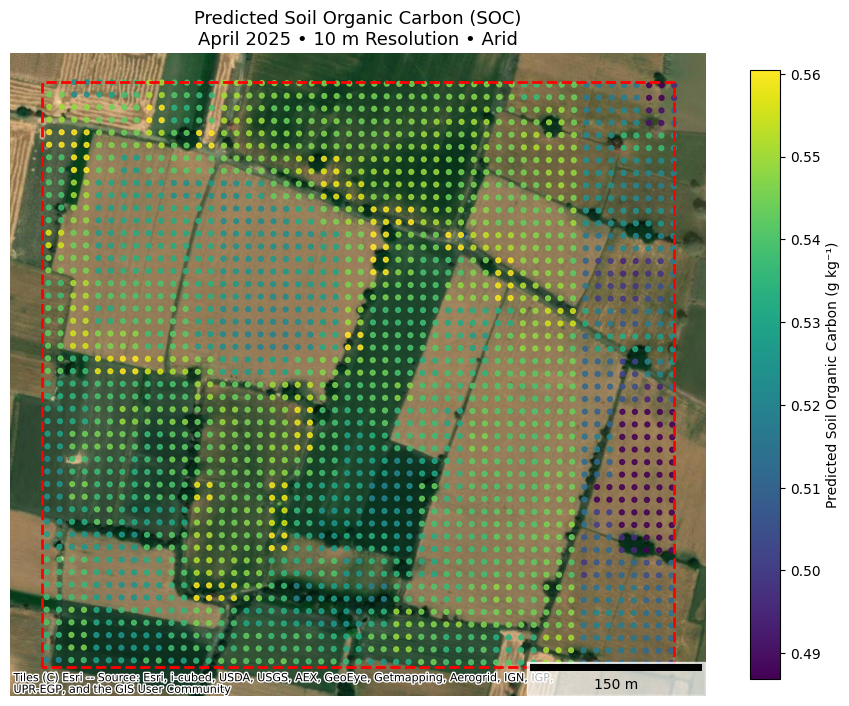

In [22]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
from shapely.geometry import Polygon
from matplotlib_scalebar.scalebar import ScaleBar

# ------------------------------------------------------------
# 1. LOAD CSV (FROM GEE EXPORT)
# ------------------------------------------------------------
path = r"H:\Final Data\April2025_OC_Predictions_RF_Vertisols.csv"
df = pd.read_csv(path)

df = df.dropna(subset=["Predicted_OC", "lat", "long"])

# ------------------------------------------------------------
# 2. POINT GEODATAFRAME (EPSG:4326 — SAME AS GEE)
# ------------------------------------------------------------
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["long"], df["lat"]),
    crs="EPSG:4326"
)

# ------------------------------------------------------------
# 3. ROI POLYGON (FROM YOUR GEE CODE)
# ------------------------------------------------------------
roi_coords = [
    (75.79582430630416, 23.42953432503332),
    (75.79582430630416, 23.42533076721332),
    (75.80078102856368, 23.42533076721332),
    (75.80078102856368, 23.42953432503332)
]

roi = gpd.GeoDataFrame(
    geometry=[Polygon(roi_coords)],
    crs="EPSG:4326"
)

# ------------------------------------------------------------
# 4. PROJECT TO WEB MERCATOR (FOR BASEMAP)
# ------------------------------------------------------------
gdf = gdf.to_crs(epsg=3857)
roi = roi.to_crs(epsg=3857)

# ------------------------------------------------------------
# 5. COLOR RANGE (VISUAL CLIP ONLY)
# ------------------------------------------------------------
vmin = gdf["Predicted_OC"].quantile(0.02)
vmax = gdf["Predicted_OC"].quantile(0.98)

# ------------------------------------------------------------
# 6. PLOT
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 9))

# SOC pixels (10 m)
gdf.plot(
    ax=ax,
    column="Predicted_OC",
    cmap="viridis",
    markersize=12,       # visually ~10 m squares
    vmin=vmin,
    vmax=vmax,
    alpha=0.85,
    legend=True,
    legend_kwds={
        "label": "Predicted Soil Organic Carbon (g kg⁻¹)",
        "shrink": 0.7
    }
)

# ROI outline
roi.boundary.plot(
    ax=ax,
    edgecolor="red",
    linewidth=2,
    linestyle="--",
    label="ROI"
)

# Satellite basemap (Google-like)
cx.add_basemap(
    ax,
    source=cx.providers.Esri.WorldImagery,
    zoom=18
)

# ------------------------------------------------------------
# 7. SCALE BAR (METERS)
# ------------------------------------------------------------
scalebar = ScaleBar(
    dx=1,
    units="m",
    location="lower right",
    length_fraction=0.25,
    box_alpha=0.7
)
ax.add_artist(scalebar)

# ------------------------------------------------------------
# 8. FINAL FORMATTING
# ------------------------------------------------------------
ax.set_title(
    "Predicted Soil Organic Carbon (SOC)\nApril 2025 • 10 m Resolution • Arid",
    fontsize=13
)

ax.set_axis_off()
plt.tight_layout()
plt.show()




# Final Code with Feature selection, Encoder, Model Saved with Hyperparameters

In [24]:
import os
import joblib
import pandas as pd
import numpy as np

from collections import defaultdict
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import OneHotEncoder
from joblib import parallel_backend

# ============================================================
# PATHS
# ============================================================
DATA_DIR  = r"H:\Final Data"
MODEL_DIR = r"H:\Final Data\SOC Models"
os.makedirs(MODEL_DIR, exist_ok=True)

# IMPORTANT: put joblib temp on a drive with space (NOT C:)
JOBLIB_TMP = r"H:\joblib_tmp"
os.makedirs(JOBLIB_TMP, exist_ok=True)
os.environ["JOBLIB_TEMP_FOLDER"] = JOBLIB_TMP

soil_files = [
    "India_SHC_Cambisols_Terrain_MERGED.csv",
    "India_SHC_Luvisols_Terrain_MERGED.csv",
    "India_SHC_Vertisols_Terrain_MERGED.csv"
]

# ============================================================
# FIXED CLIMATE ZONES (KNOWN A-PRIORI)
# ============================================================
CLIMATE_ZONES = ["Tropical", "Arid", "Temperate", "Cold", "Polar"]

# ============================================================
# FEATURE ENGINEERING
# ============================================================
def feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    eps = 1e-6

    df["date"] = pd.to_datetime(df.get("date"), errors="coerce")
    df["SAR_DATE"] = pd.to_datetime(df.get("SAR_DATE"), errors="coerce")

    # Vegetation
    df["NDVI"] = (df["B8"] - df["B4"]) / (df["B8"] + df["B4"] + eps)
    df["EVI"]  = 2.5 * (df["B8"] - df["B4"]) / (df["B8"] + 6*df["B4"] - 7.5*df["B2"] + 1)
    df["SAVI"] = 1.5 * (df["B8"] - df["B4"]) / (df["B8"] + df["B4"] + 0.5)

    # Red-edge
    df["NDRE"]  = (df["B8"] - df["B5"]) / (df["B8"] + df["B5"] + eps)
    df["CI_RE"] = (df["B8"] / (df["B5"] + eps)) - 1

    # Soil
    df["BSI"] = (
        (df["B11"] + df["B4"] - df["B8"] - df["B2"]) /
        (df["B11"] + df["B4"] + df["B8"] + df["B2"] + eps)
    )
    df["NDTI"] = (df["B11"] - df["B12"]) / (df["B11"] + df["B12"] + eps)
    df["BI"]   = np.sqrt(df["B4"]**2 + df["B3"]**2)

    # Moisture
    df["NDWI"] = (df["B8"] - df["B11"]) / (df["B8"] + df["B11"] + eps)
    df["LSWI"] = (df["B8"] - df["B12"]) / (df["B8"] + df["B12"] + eps)

    # SAR
    df["VV_VH_ratio"] = df["VV"] / (df["VH"] + eps)
    df["VV_minus_VH"] = df["VV"] - df["VH"]
    df["log_VV"]      = np.log(np.abs(df["VV"]) + 1)
    df["log_VH"]      = np.log(np.abs(df["VH"]) + 1)

    # Terrain
    df["slope_norm"]     = np.log1p(df["slope"])
    df["elev_range_90m"] = df["elev_max_90m"] - df["elev_min_90m"]

    return df

# ============================================================
# METRICS
# ============================================================
def regression_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred))
    }

# ============================================================
# RF FACTORY
# ============================================================
def make_rf():
    return RandomForestRegressor(
        n_estimators=600,
        max_features=0.5,
        min_samples_leaf=4,
        random_state=42,
        n_jobs=-1
    )

# ============================================================
# MAIN LOOP — ALL SOILS
# ============================================================
for file in soil_files:

    soil_name = file.split("_")[2]
    print(f"\n================ {soil_name.upper()} =================")

    # --------------------------------------------------------
    # LOAD + FEATURE ENGINEERING
    # --------------------------------------------------------
    df = pd.read_csv(os.path.join(DATA_DIR, file))
    df = feature_engineering(df)

    target = "OC"
    groups = df["tile_id"]

    drop_cols = [
        "system:index", ".geo",
        "date", "SAR_DATE", "tile_date",
        "SOIL_CLASS", "tile_id", target,
        "Band_SCL", "cloud_cover",
        "days_from_survey", "lat", "long"
    ]

    X = df.drop(columns=drop_cols, errors="ignore")
    y = df[target].astype(float)

    # --------------------------------------------------------
    # ONE-HOT ENCODING (DEPLOYMENT SAFE)
    # --------------------------------------------------------
    cat_cols = ["CLIMATE_ZONE"]
    for c in cat_cols:
        if c not in X.columns:
            X[c] = np.nan

    num_cols = X.columns.difference(cat_cols)

    encoder = OneHotEncoder(
        categories=[CLIMATE_ZONES],
        handle_unknown="ignore",
        sparse_output=False
    )

    X_cat = encoder.fit_transform(X[cat_cols])
    cat_feature_names = encoder.get_feature_names_out(cat_cols)

    X_enc = pd.DataFrame(X_cat, columns=cat_feature_names, index=X.index)
    X_final = pd.concat([X[num_cols], X_enc], axis=1)

    X_final = X_final.apply(pd.to_numeric, errors="coerce").astype(np.float32)
    y = y.astype(np.float32)

    # --------------------------------------------------------
    # SPATIAL PERMUTATION IMPORTANCE
    # --------------------------------------------------------
    gkf = GroupKFold(n_splits=5)
    feature_importance = defaultdict(list)

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X_final, y, groups)):
        print(f"Permutation importance — Fold {fold+1}")

        model = make_rf()
        model.fit(X_final.iloc[train_idx], y.iloc[train_idx])

        with parallel_backend("threading"):
            result = permutation_importance(
                model,
                X_final.iloc[test_idx],
                y.iloc[test_idx],
                n_repeats=5,
                scoring="r2",
                random_state=42,
                n_jobs=1,
                max_samples=0.7
            )

        for i, col in enumerate(X_final.columns):
            feature_importance[col].append(float(result.importances_mean[i]))

    imp_df = pd.DataFrame(feature_importance).T
    imp_df["mean_importance"] = imp_df.mean(axis=1)
    imp_df = imp_df.sort_values("mean_importance", ascending=False)

    selected_features = imp_df[imp_df["mean_importance"] > 0].index.tolist()
    print(f"Selected {len(selected_features)} / {X_final.shape[1]} features")

    # --------------------------------------------------------
    # SPATIAL CV WITH SELECTED FEATURES
    # --------------------------------------------------------
    X_sel = X_final[selected_features]

    r2s, rmses, maes = [], [], []

    for train_idx, test_idx in gkf.split(X_sel, y, groups):
        model = make_rf()
        model.fit(X_sel.iloc[train_idx], y.iloc[train_idx])
        preds = model.predict(X_sel.iloc[test_idx])

        m = regression_metrics(y.iloc[test_idx], preds)
        r2s.append(m["R2"])
        rmses.append(m["RMSE"])
        maes.append(m["MAE"])

    metrics_summary = {
        "R2_mean": float(np.mean(r2s)),
        "RMSE_mean": float(np.mean(rmses)),
        "MAE_mean": float(np.mean(maes))
    }

    print(metrics_summary)

    # --------------------------------------------------------
    # FINAL TRAINING + SAVE
    # --------------------------------------------------------
    final_model = make_rf()
    final_model.fit(X_sel, y)

    final_hyperparameters = final_model.get_params()

    deployment_object = {
        "model": final_model,
        "encoder": encoder,
        "features": selected_features,
        "numeric_features": list(num_cols),
        "categorical_features": cat_cols,
        "target": target,
        "soil_type": soil_name,
        "training_metrics": metrics_summary,
        "climate_zones": CLIMATE_ZONES,
        "model_hyperparameters": final_hyperparameters
    }

    out_path = os.path.join(
        MODEL_DIR, f"SOC_RF_{soil_name}_DEPLOYMENT.pkl"
    )
    joblib.dump(deployment_object, out_path)

    print(f"{soil_name.upper()} MODEL + ENCODER + PARAMS SAVED ✔ -> {out_path}")

print("\nALL SOIL MODELS TRAINED — DEPLOYMENT READY ✔✔")



================ CAMBISOLS =================
Permutation importance — Fold 1
Permutation importance — Fold 2
Permutation importance — Fold 3
Permutation importance — Fold 4
Permutation importance — Fold 5
Selected 49 / 50 features
{'R2_mean': 0.4416946840989846, 'RMSE_mean': 0.18357762254800794, 'MAE_mean': 0.1259499036014869}
CAMBISOLS MODEL + ENCODER + PARAMS SAVED ✔ -> H:\Final Data\SOC Models\SOC_RF_Cambisols_DEPLOYMENT.pkl

================ LUVISOLS =================
Permutation importance — Fold 1
Permutation importance — Fold 2
Permutation importance — Fold 3
Permutation importance — Fold 4
Permutation importance — Fold 5
Selected 24 / 50 features
{'R2_mean': 0.22870986556310066, 'RMSE_mean': 0.22004784228467686, 'MAE_mean': 0.14492328542300895}
LUVISOLS MODEL + ENCODER + PARAMS SAVED ✔ -> H:\Final Data\SOC Models\SOC_RF_Luvisols_DEPLOYMENT.pkl

================ VERTISOLS =================


C:\Users\grs05\AppData\Local\Temp\ipykernel_9984\2125139868.py:43: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df.get("date"), errors="coerce")
C:\Users\grs05\AppData\Local\Temp\ipykernel_9984\2125139868.py:44: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["SAR_DATE"] = pd.to_datetime(df.get("SAR_DATE"), errors="coerce")


Permutation importance — Fold 1
Permutation importance — Fold 2
Permutation importance — Fold 3
Permutation importance — Fold 4
Permutation importance — Fold 5
Selected 10 / 50 features
{'R2_mean': 0.18038982087235886, 'RMSE_mean': 0.28020799102021693, 'MAE_mean': 0.19605609277300204}
VERTISOLS MODEL + ENCODER + PARAMS SAVED ✔ -> H:\Final Data\SOC Models\SOC_RF_Vertisols_DEPLOYMENT.pkl

ALL SOIL MODELS TRAINED — DEPLOYMENT READY ✔✔


# Saving PPD models for Veritsol Soil Type

In [25]:
# ============================================================
# STAGE A: TRAIN + SAVE MONTE CARLO REGRESSION KRIGING ENSEMBLE
# (WITH VARIOGRAM SUBSAMPLING FOR SCALABILITY)
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from skgstat import Variogram

# ============================================================
# PATHS
# ============================================================
DATA_FILE = r"H:\Final Data\India_SHC_Vertisols_Terrain_MERGED.csv"
BASE_DEPLOYMENT = r"H:\Final Data\SOC Models\SOC_RF_Vertisols_DEPLOYMENT.pkl"
OUT_DIR = r"H:\Final Data\PPD Models"
os.makedirs(OUT_DIR, exist_ok=True)

# ============================================================
# PARAMETERS
# ============================================================
M = 100
TRAIN_FRAC = 0.70
VARIOGRAM_SAMPLE_SIZE = 8000   # << SCALABILITY CONTROL
R = 6371000.0
np.random.seed(42)

# ============================================================
# LOAD BASE DEPLOYMENT OBJECT
# ============================================================
base = joblib.load(BASE_DEPLOYMENT)

encoder = base["encoder"]
selected_features = base["features"]
rf_params = base["model_hyperparameters"]
target = base["target"]

# ============================================================
# FEATURE ENGINEERING (UNCHANGED)
# ============================================================
def feature_engineering(df):
    eps = 1e-6

    df["date"] = pd.to_datetime(df.get("date"), errors="coerce")
    df["SAR_DATE"] = pd.to_datetime(df.get("SAR_DATE"), errors="coerce")

    df["NDVI"] = (df["B8"] - df["B4"]) / (df["B8"] + df["B4"] + eps)
    df["EVI"]  = 2.5 * (df["B8"] - df["B4"]) / (df["B8"] + 6*df["B4"] - 7.5*df["B2"] + 1)
    df["SAVI"] = 1.5 * (df["B8"] - df["B4"]) / (df["B8"] + df["B4"] + 0.5)

    df["NDRE"]  = (df["B8"] - df["B5"]) / (df["B8"] + df["B5"] + eps)
    df["CI_RE"] = (df["B8"] / (df["B5"] + eps)) - 1

    df["BSI"] = (
        (df["B11"] + df["B4"] - df["B8"] - df["B2"]) /
        (df["B11"] + df["B4"] + df["B8"] + df["B2"] + eps)
    )
    df["NDTI"] = (df["B11"] - df["B12"]) / (df["B11"] + df["B12"] + eps)
    df["BI"]   = np.sqrt(df["B4"]**2 + df["B3"]**2)

    df["NDWI"] = (df["B8"] - df["B11"]) / (df["B8"] + df["B11"] + eps)
    df["LSWI"] = (df["B8"] - df["B12"]) / (df["B8"] + df["B12"] + eps)

    df["VV_VH_ratio"] = df["VV"] / (df["VH"] + eps)
    df["VV_minus_VH"] = df["VV"] - df["VH"]
    df["log_VV"]      = np.log(np.abs(df["VV"]) + 1)
    df["log_VH"]      = np.log(np.abs(df["VH"]) + 1)

    df["slope_norm"]     = np.log1p(df["slope"])
    df["elev_range_90m"] = df["elev_max_90m"] - df["elev_min_90m"]

    return df.replace([np.inf, -np.inf], np.nan)

# ============================================================
# LOAD + PREP DATA
# ============================================================
df = pd.read_csv(DATA_FILE)
df = feature_engineering(df)

y = df[target].astype(float)

drop_cols = [
    "system:index", ".geo",
    "date", "SAR_DATE", "tile_date",
    "SOIL_CLASS", "tile_id", target,
    "Band_SCL", "cloud_cover",
    "days_from_survey", "lat", "long"
]

X = df.drop(columns=drop_cols, errors="ignore")

cat_cols = ["CLIMATE_ZONE"]
num_cols = X.columns.difference(cat_cols)

X_cat = encoder.transform(X[cat_cols])
X_cat = pd.DataFrame(
    X_cat,
    columns=encoder.get_feature_names_out(cat_cols),
    index=X.index
)

X_final = pd.concat([X[num_cols], X_cat], axis=1)
X_final = X_final[selected_features].astype(np.float32)

# ============================================================
# MONTE CARLO LOOP (SAVE EACH REALIZATION)
# ============================================================
for m in range(M):

    print(f"Saving RK realization {m+1}/{M}")

    # -----------------------------
    # 1. Resample & train RF
    # -----------------------------
    X_m, _, y_m, _ = train_test_split(
        X_final, y,
        train_size=TRAIN_FRAC,
        random_state=42 + m
    )

    rf = RandomForestRegressor(**rf_params)
    rf.fit(X_m, y_m)

    # -----------------------------
    # 2. Residuals
    # -----------------------------
    residuals = y_m.values - rf.predict(X_m)

    # -----------------------------
    # 3. Coordinates → meters
    # -----------------------------
    lon = np.deg2rad(df.loc[X_m.index, "long"].values)
    lat = np.deg2rad(df.loc[X_m.index, "lat"].values)

    lon0 = lon.mean()
    lat0 = lat.mean()

    x = (lon - lon0) * np.cos(lat0) * R
    y_coord = (lat - lat0) * R
    coords = np.column_stack([x, y_coord])

    # -----------------------------
    # 4. SUBSAMPLE FOR VARIOGRAM
    # -----------------------------
    n_total = coords.shape[0]

    if n_total > VARIOGRAM_SAMPLE_SIZE:
        rng = np.random.default_rng(10_000 + m)
        idx = rng.choice(
            n_total,
            VARIOGRAM_SAMPLE_SIZE,
            replace=False
        )
        coords_v = coords[idx]
        residuals_v = residuals[idx]
    else:
        coords_v = coords
        residuals_v = residuals

    # -----------------------------
    # 5. Fit variogram
    # -----------------------------
    V = Variogram(
        coords_v,
        residuals_v,
        model="spherical",
        n_lags=15,
        maxlag="auto",
        normalize=False
    )

    range_m, sill_m, nugget_m = V.parameters
    nugget_m = max(nugget_m, 0.05 * sill_m)

    # -----------------------------
    # 6. Save deployable object
    # -----------------------------
    rk_object = {
        "rf_model": rf,
        "encoder": encoder,
        "features": selected_features,
        "variogram": {
            "model": "spherical",
            "range_m": range_m,
            "sill": sill_m,
            "nugget": nugget_m,
            "n_samples": len(coords_v)
        },
        "projection": {
            "lon0_rad": lon0,
            "lat0_rad": lat0,
            "earth_radius_m": R
        },
        "soil_type": "Vertisols",
        "mc_id": m
    }

    joblib.dump(
        rk_object,
        os.path.join(OUT_DIR, f"SOC_RK_MC_{m:03d}.pkl")
    )

print("✔ Monte Carlo RK ensemble saved")




Saving RK realization 1/100
Saving RK realization 2/100
Saving RK realization 3/100
Saving RK realization 4/100
Saving RK realization 5/100
Saving RK realization 6/100
Saving RK realization 7/100
Saving RK realization 8/100
Saving RK realization 9/100
Saving RK realization 10/100
Saving RK realization 11/100
Saving RK realization 12/100
Saving RK realization 13/100
Saving RK realization 14/100
Saving RK realization 15/100
Saving RK realization 16/100
Saving RK realization 17/100
Saving RK realization 18/100
Saving RK realization 19/100
Saving RK realization 20/100
Saving RK realization 21/100
Saving RK realization 22/100
Saving RK realization 23/100
Saving RK realization 24/100
Saving RK realization 25/100
Saving RK realization 26/100
Saving RK realization 27/100
Saving RK realization 28/100
Saving RK realization 29/100
Saving RK realization 30/100
Saving RK realization 31/100
Saving RK realization 32/100
Saving RK realization 33/100
Saving RK realization 34/100
Saving RK realization 3

# Monte carlo Simulation on vertisols (one farm pixel)


Posterior Predictive Distribution (SOC)
Mean : 0.5024
Std  : 0.1510
P05  : 0.2334
P50  : 0.5023
P95  : 0.7629


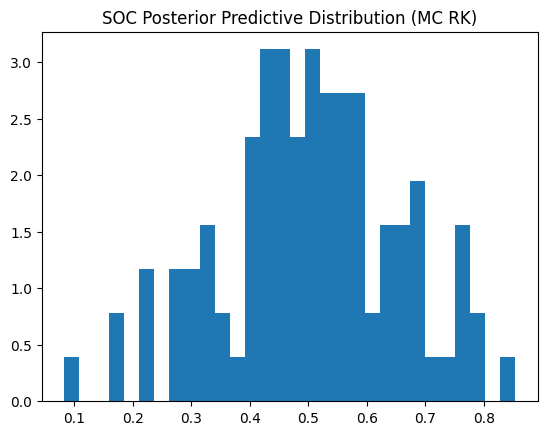

In [26]:

# # ============================================================
# STAGE B: DEPLOY MONTE CARLO RK ENSEMBLE
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PATH
# ============================================================
MODEL_DIR = r"H:\Final Data\PPD Models"

# ============================================================
# FEATURE ENGINEERING (IDENTICAL)
# ============================================================
def feature_engineering(df):
    eps = 1e-6

    df["date"] = pd.to_datetime(df.get("date"), errors="coerce")
    df["SAR_DATE"] = pd.to_datetime(df.get("SAR_DATE"), errors="coerce")

    df["NDVI"] = (df["B8"] - df["B4"]) / (df["B8"] + df["B4"] + eps)
    df["EVI"]  = 2.5 * (df["B8"] - df["B4"]) / (df["B8"] + 6*df["B4"] - 7.5*df["B2"] + 1)
    df["SAVI"] = 1.5 * (df["B8"] - df["B4"]) / (df["B8"] + df["B4"] + 0.5)

    df["NDRE"]  = (df["B8"] - df["B5"]) / (df["B8"] + df["B5"] + eps)
    df["CI_RE"] = (df["B8"] / (df["B5"] + eps)) - 1

    df["BSI"] = (
        (df["B11"] + df["B4"] - df["B8"] - df["B2"]) /
        (df["B11"] + df["B4"] + df["B8"] + df["B2"] + eps)
    )
    df["NDTI"] = (df["B11"] - df["B12"]) / (df["B11"] + df["B12"] + eps)
    df["BI"]   = np.sqrt(df["B4"]**2 + df["B3"]**2)

    df["NDWI"] = (df["B8"] - df["B11"]) / (df["B8"] + df["B11"] + eps)
    df["LSWI"] = (df["B8"] - df["B12"]) / (df["B8"] + df["B12"] + eps)

    df["VV_VH_ratio"] = df["VV"] / (df["VH"] + eps)
    df["VV_minus_VH"] = df["VV"] - df["VH"]
    df["log_VV"]      = np.log(np.abs(df["VV"]) + 1)
    df["log_VH"]      = np.log(np.abs(df["VH"]) + 1)

    df["slope_norm"]     = np.log1p(df["slope"])
    df["elev_range_90m"] = df["elev_max_90m"] - df["elev_min_90m"]

    return df.replace([np.inf, -np.inf], np.nan)

# ============================================================
# NEW POINT (FULL FEATURE SET)
# ============================================================
new_point = pd.DataFrame([{
    "B11":0.43385,"B12":0.3101,"B2":0.1547,"B3":0.2179,"B4":0.31245,
    "B5":0.35195,"B6":0.3716,"B7":0.38655,"B8":0.40125,"B8A":0.41615,
    "LS_factor":0,"R_factor":505.58197,"SPI":0,"TPI_300m":0.6954956,
    "TPI_600m":1.6795044,"TWI":6.915580138,"VH":-21.68163658,
    "VV":-13.68022677,"aspect_cos":1,"aspect_sin":0,
    "elev_max_90m":516,"elev_mean_90m":514.253,"elev_min_90m":513,
    "elev_std_90m":0.769503399,"elevation":515,"lat":23.42953396,
    "log_flow_acc":0.007824859,"long":75.79608126,"plan_curvature":0,
    "profile_curvature":0,"slope":0,
    "CLIMATE_ZONE":"Arid",
    "date":"2025-04-15",
    "SAR_DATE":"2025-04-10",
    "tile_date":"20250415"
}])

new_point = feature_engineering(new_point)

# ============================================================
# LOAD ENSEMBLE + PREDICT
# ============================================================
soc_samples = []

for fname in sorted(os.listdir(MODEL_DIR)):
    if not fname.startswith("SOC_RK_MC_"):
        continue

    rk = joblib.load(os.path.join(MODEL_DIR, fname))

    rf = rk["rf_model"]
    encoder = rk["encoder"]
    features = rk["features"]
    vario = rk["variogram"]

    X_cat = encoder.transform(new_point[["CLIMATE_ZONE"]])
    X_cat = pd.DataFrame(
        X_cat,
        columns=encoder.get_feature_names_out(["CLIMATE_ZONE"])
    )

    X_new = pd.concat(
        [new_point.drop(columns=["CLIMATE_ZONE"]), X_cat],
        axis=1
    )

    X_new = X_new.reindex(columns=features, fill_value=0).astype(np.float32)

    f_hat = rf.predict(X_new)[0]

    sigma2 = vario["sill"] + vario["nugget"]
    w = np.random.normal(0, np.sqrt(sigma2))

    soc_samples.append(f_hat + w)

soc_samples = np.array(soc_samples)

# ============================================================
# PPD SUMMARY
# ============================================================
print("\nPosterior Predictive Distribution (SOC)")
print(f"Mean : {soc_samples.mean():.4f}")
print(f"Std  : {soc_samples.std():.4f}")
print(f"P05  : {np.percentile(soc_samples,5):.4f}")
print(f"P50  : {np.percentile(soc_samples,50):.4f}")
print(f"P95  : {np.percentile(soc_samples,95):.4f}")

plt.hist(soc_samples, bins=30, density=True)
plt.title("SOC Posterior Predictive Distribution (MC RK)")
plt.show()


# monte carlo sim on full farm


Extracted Soil Texture
Sand (%): 52.0
Silt (%): 24.0
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

Posterior Predictive Distribution (SOC Stock)
Mean : 2.41 t/ha
Std  : 0.72
P05  : 1.33
P50  : 2.45
P95  : 3.64


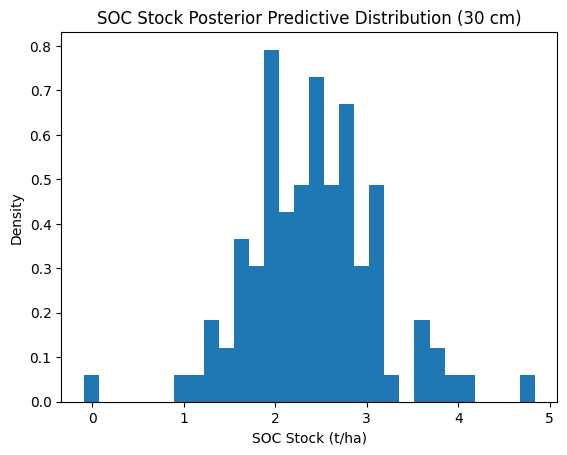

In [28]:
# ============================================================
# FULL PIPELINE: SOC PPD → BD → SOC STOCK PPD (30 cm)
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

# ============================================================
# PATHS
# ============================================================
MODEL_DIR_SOC = r"H:\Final Data\PPD Models"

SAND_RASTER = r"H:\Carbon_Data\Soil Texture Maps\sand.tot_iso.11277.2020.wpct_m_30m_b0cm..30cm_20200101_20221231_g_epsg.4326_v20250523.tif"
SILT_RASTER = r"H:\Carbon_Data\Soil Texture Maps\silt.tot_iso.11277.2020.wpct_m_30m_b0cm..30cm_20200101_20221231_g_epsg.4326_v20250523.tif"

BD_MODEL_PATH = r"H:\Carbon_Data\BD_Models\BD_model_Vertisols.joblib"

DEPTH_CM = 30.0

# ============================================================
# FEATURE ENGINEERING (IDENTICAL TO TRAINING)
# ============================================================
def feature_engineering(df):

    eps = 1e-6

    df["date"] = pd.to_datetime(df.get("date"), errors="coerce")
    df["SAR_DATE"] = pd.to_datetime(df.get("SAR_DATE"), errors="coerce")

    df["NDVI"] = (df["B8"] - df["B4"]) / (df["B8"] + df["B4"] + eps)
    df["EVI"]  = 2.5 * (df["B8"] - df["B4"]) / (df["B8"] + 6*df["B4"] - 7.5*df["B2"] + 1)
    df["SAVI"] = 1.5 * (df["B8"] - df["B4"]) / (df["B8"] + df["B4"] + 0.5)

    df["NDRE"]  = (df["B8"] - df["B5"]) / (df["B8"] + df["B5"] + eps)
    df["CI_RE"] = (df["B8"] / (df["B5"] + eps)) - 1

    df["BSI"] = (
        (df["B11"] + df["B4"] - df["B8"] - df["B2"]) /
        (df["B11"] + df["B4"] + df["B8"] + df["B2"] + eps)
    )

    df["NDTI"] = (df["B11"] - df["B12"]) / (df["B11"] + df["B12"] + eps)
    df["BI"]   = np.sqrt(df["B4"]**2 + df["B3"]**2)

    df["NDWI"] = (df["B8"] - df["B11"]) / (df["B8"] + df["B11"] + eps)
    df["LSWI"] = (df["B8"] - df["B12"]) / (df["B8"] + df["B12"] + eps)

    df["VV_VH_ratio"] = df["VV"] / (df["VH"] + eps)
    df["VV_minus_VH"] = df["VV"] - df["VH"]
    df["log_VV"]      = np.log(np.abs(df["VV"]) + 1)
    df["log_VH"]      = np.log(np.abs(df["VH"]) + 1)

    df["slope_norm"]     = np.log1p(df["slope"])
    df["elev_range_90m"] = df["elev_max_90m"] - df["elev_min_90m"]

    return df.replace([np.inf, -np.inf], np.nan)

# ============================================================
# RASTER SAMPLING FUNCTION
# ============================================================
def sample_raster(raster_path, lon, lat):
    with rasterio.open(raster_path) as src:
        val = list(src.sample([(lon, lat)]))[0][0]
    return float(val)

# ============================================================
# NEW SITE / POINT
# ============================================================
new_point = pd.DataFrame([{
    "B11":0.43385,"B12":0.3101,"B2":0.1547,"B3":0.2179,"B4":0.31245,
    "B5":0.35195,"B6":0.3716,"B7":0.38655,"B8":0.40125,"B8A":0.41615,
    "LS_factor":0,"R_factor":505.58197,"SPI":0,"TPI_300m":0.6954956,
    "TPI_600m":1.6795044,"TWI":6.915580138,"VH":-21.68163658,
    "VV":-13.68022677,"aspect_cos":1,"aspect_sin":0,
    "elev_max_90m":516,"elev_mean_90m":514.253,"elev_min_90m":513,
    "elev_std_90m":0.769503399,"elevation":515,"lat":23.42953396,
    "log_flow_acc":0.007824859,"long":75.79608126,"plan_curvature":0,
    "profile_curvature":0,"slope":0,
    "CLIMATE_ZONE":"Arid",
    "date":"2025-04-15",
    "SAR_DATE":"2025-04-10",
    "tile_date":"20250415"
}])

new_point = feature_engineering(new_point)

lat = float(new_point["lat"].iloc[0])
lon = float(new_point["long"].iloc[0])

# ============================================================
# EXTRACT SAND & SILT (%)
# ============================================================
sand = sample_raster(SAND_RASTER, lon, lat)
silt = sample_raster(SILT_RASTER, lon, lat)

print("\nExtracted Soil Texture")
print("Sand (%):", sand)
print("Silt (%):", silt)

# ============================================================
# LOAD BULK DENSITY MODEL
# ============================================================
bd_model = joblib.load(BD_MODEL_PATH)

def predict_bd(soc_value):

    X_bd = pd.DataFrame([{
        "orgc_value_avg": soc_value,
        "sand_value_avg": sand,
        "silt_value_avg": silt
    }])

    return bd_model.predict(X_bd)[0]

# ============================================================
# DEPLOY SOC ENSEMBLE
# ============================================================
soc_samples = []

for fname in sorted(os.listdir(MODEL_DIR_SOC)):

    if not fname.startswith("SOC_RK_MC_"):
        continue

    rk = joblib.load(os.path.join(MODEL_DIR_SOC, fname))

    rf = rk["rf_model"]
    encoder = rk["encoder"]
    features = rk["features"]
    vario = rk["variogram"]

    X_cat = encoder.transform(new_point[["CLIMATE_ZONE"]])
    X_cat = pd.DataFrame(
        X_cat,
        columns=encoder.get_feature_names_out(["CLIMATE_ZONE"])
    )

    X_new = pd.concat(
        [new_point.drop(columns=["CLIMATE_ZONE"]), X_cat],
        axis=1
    )

    X_new = X_new.reindex(columns=features, fill_value=0).astype(np.float32)

    f_hat = rf.predict(X_new)[0]

    sigma2 = vario["sill"] + vario["nugget"]
    w = np.random.normal(0, np.sqrt(sigma2))

    soc_samples.append(f_hat + w)

soc_samples = np.array(soc_samples)

# ============================================================
# SOC STOCK MONTE CARLO PROPAGATION
# ============================================================
stock_samples = []

for soc in soc_samples:

    bd = predict_bd(soc)

    # SOC Stock Equation
    stock = soc * bd * DEPTH_CM * 0.1

    stock_samples.append(stock)

stock_samples = np.array(stock_samples)

# ============================================================
# PPD SUMMARY – SOC STOCK
# ============================================================
print("\nPosterior Predictive Distribution (SOC Stock)")
print(f"Mean : {stock_samples.mean():.2f} t/ha")
print(f"Std  : {stock_samples.std():.2f}")
print(f"P05  : {np.percentile(stock_samples,5):.2f}")
print(f"P50  : {np.percentile(stock_samples,50):.2f}")
print(f"P95  : {np.percentile(stock_samples,95):.2f}")

# ============================================================
# PLOT
# ============================================================
plt.hist(stock_samples, bins=30, density=True)
plt.title("SOC Stock Posterior Predictive Distribution (30 cm)")
plt.xlabel("SOC Stock (t/ha)")
plt.ylabel("Density")
plt.show()


